In [4]:
# =========================
# CELL 0: SETUP - MÅSTE KÖRAS FÖRST
# =========================

import pandas as pd
import numpy as np
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest

try:
    import umap.umap_ as umap
    print("UMAP finns installerat.")
except ModuleNotFoundError:
    print("UMAP saknas. Kör i terminalen: pip install umap-learn")

sns.set(style="whitegrid")

project_folder = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

df_dup = pd.read_csv(project_folder / "data" / "spotify_cleaned_with_duplicates.csv")
df_unique = pd.read_csv(project_folder / "data" / "spotify_cleaned_unique_tracks.csv")

print("df_dup:", df_dup.shape)
print("df_unique:", df_unique.shape)

audio_features = [
    "danceability",
    "energy",
    "loudness",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo",
    "duration_min"
]

target_context = ["popularity", "track_genre", "track_name", "artists", "track_id"]

df_model = df_unique[audio_features + target_context].dropna().copy()

X = df_model[audio_features].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("df_model:", df_model.shape)
df_model.head()

c:\Users\spiri\ws\hitsong_uml\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


UMAP finns installerat.
df_dup: (113999, 21)
df_unique: (89740, 21)
df_model: (89583, 15)


,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_min,popularity,track_genre,track_name,artists,track_id
0,0.676,0.4610,-6.746,0.1430,0.0322,0.000001,0.3580,0.715,87.917,3.844433,73,acoustic,Comedy,Gen Hoshino,5SuOikwiRyPMVoIQDJUgSV
1,0.420,0.1660,-17.235,0.0763,0.9240,0.000006,0.1010,0.267,77.489,2.493500,55,acoustic,Ghost - Acoustic,Ben Woodward,4qPNDBW1i3p13qLCt0Ki3A
2,0.438,0.3590,-9.734,0.0557,0.2100,0.000000,0.1170,0.120,76.332,3.513767,57,acoustic,To Begin Again,Ingrid Michaelson;ZAYN,1iJBSr7s7jYXzM8EGcbK5b
3,0.266,0.0596,-18.515,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3.365550,71,acoustic,Can't Help Falling In Love,Kina Grannis,6lfxq3CG4xtTiEg7opyCyx
4,0.618,0.4430,-9.681,0.0526,0.4690,0.000000,0.0829,0.167,119.949,3.314217,82,acoustic,Hold On,Chord Overstreet,5vjLSffimiIP26QG5WcN2K


In [5]:
# =========================
# CELL 1: IMPORTS
# =========================
# Vi importerar bibliotek för:
# - datahantering
# - visualisering
# - skalning
# - klustring
# - dimensionsreduktion
# - anomalidetektion

import pandas as pd
import numpy as np
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest

sns.set(style="whitegrid")

In [6]:
# =========================
# CELL 2: LOAD CLEANED DATASETS
# =========================
# Dataset 1: behåller dubbletter
# Används för genreanalys och frågan:
# "Kan samma låt finnas i flera genres?"

# Dataset 2: en rad per låt
# Används för ML/klustring så att samma låt inte påverkar modellen flera gånger.

project_folder = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

df_dup = pd.read_csv(project_folder / "data" / "spotify_cleaned_with_duplicates.csv")
df_unique = pd.read_csv(project_folder / "data" / "spotify_cleaned_unique_tracks.csv")

print("Med dubbletter:", df_dup.shape)
print("Unika låtar:", df_unique.shape)

df_unique.head()

Med dubbletter: (113999, 21)
Unika låtar: (89740, 21)


,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,...,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,duration_min
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,...,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4.0,acoustic,3.844433
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,...,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4.0,acoustic,2.493500
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,...,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4.0,acoustic,3.513767
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,...,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3.0,acoustic,3.365550
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,...,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4.0,acoustic,3.314217


In [7]:
# =========================
# CELL 3: DATASET OVERVIEW
# =========================
# Här visar vi storlek, kolumner och datatyper.
# Detta behövs i presentationen: "Vad består datasetet av?"

print("Antal rader och kolumner, med dubbletter:", df_dup.shape)
print("Antal rader och kolumner, unika låtar:", df_unique.shape)

print("\nKolumner:")
print(df_unique.columns.tolist())

print("\nDatatyper:")
df_unique.info()

Antal rader och kolumner, med dubbletter: (113999, 21)
Antal rader och kolumner, unika låtar: (89740, 21)

Kolumner:
['track_id', 'artists', 'album_name', 'track_name', 'popularity', 'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'track_genre', 'duration_min']

Datatyper:
<class 'pandas.DataFrame'>
RangeIndex: 89740 entries, 0 to 89739
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   track_id          89740 non-null  str    
 1   artists           89740 non-null  str    
 2   album_name        89740 non-null  str    
 3   track_name        89740 non-null  str    
 4   popularity        89740 non-null  int64  
 5   duration_ms       89740 non-null  int64  
 6   explicit          89740 non-null  bool   
 7   danceability      89740 non-null  float64
 8   energy            89

In [8]:
# =========================
# CELL 4: SELECT AUDIO FEATURES
# =========================
# Dessa variabler beskriver låtens ljudprofil.
# De passar bra för unsupervised learning eftersom vi vill hitta låttyper utan färdiga etiketter.

audio_features = [
    "danceability",
    "energy",
    "loudness",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo",
    "duration_min"
]

target_context = ["popularity", "track_genre", "track_name", "artists"]

df_model = df_unique[audio_features + target_context].dropna().copy()

print("Data för modellering:", df_model.shape)
df_model.head()

Data för modellering: (89583, 14)


,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_min,popularity,track_genre,track_name,artists
0,0.676,0.4610,-6.746,0.1430,0.0322,0.000001,0.3580,0.715,87.917,3.844433,73,acoustic,Comedy,Gen Hoshino
1,0.420,0.1660,-17.235,0.0763,0.9240,0.000006,0.1010,0.267,77.489,2.493500,55,acoustic,Ghost - Acoustic,Ben Woodward
2,0.438,0.3590,-9.734,0.0557,0.2100,0.000000,0.1170,0.120,76.332,3.513767,57,acoustic,To Begin Again,Ingrid Michaelson;ZAYN
3,0.266,0.0596,-18.515,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3.365550,71,acoustic,Can't Help Falling In Love,Kina Grannis
4,0.618,0.4430,-9.681,0.0526,0.4690,0.000000,0.0829,0.167,119.949,3.314217,82,acoustic,Hold On,Chord Overstreet


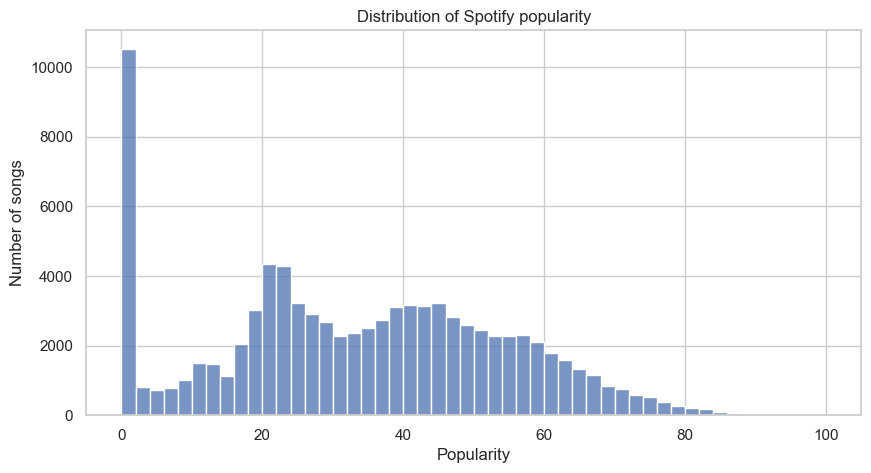

In [9]:
# =========================
# CELL 5: EDA - POPULARITY DISTRIBUTION
# =========================
# Fråga:
# Är hits vanliga eller ovanliga i datasetet?

plt.figure(figsize=(10, 5))
sns.histplot(df_model["popularity"], bins=50)

plt.title("Distribution of Spotify popularity")
plt.xlabel("Popularity")
plt.ylabel("Number of songs")
plt.show()

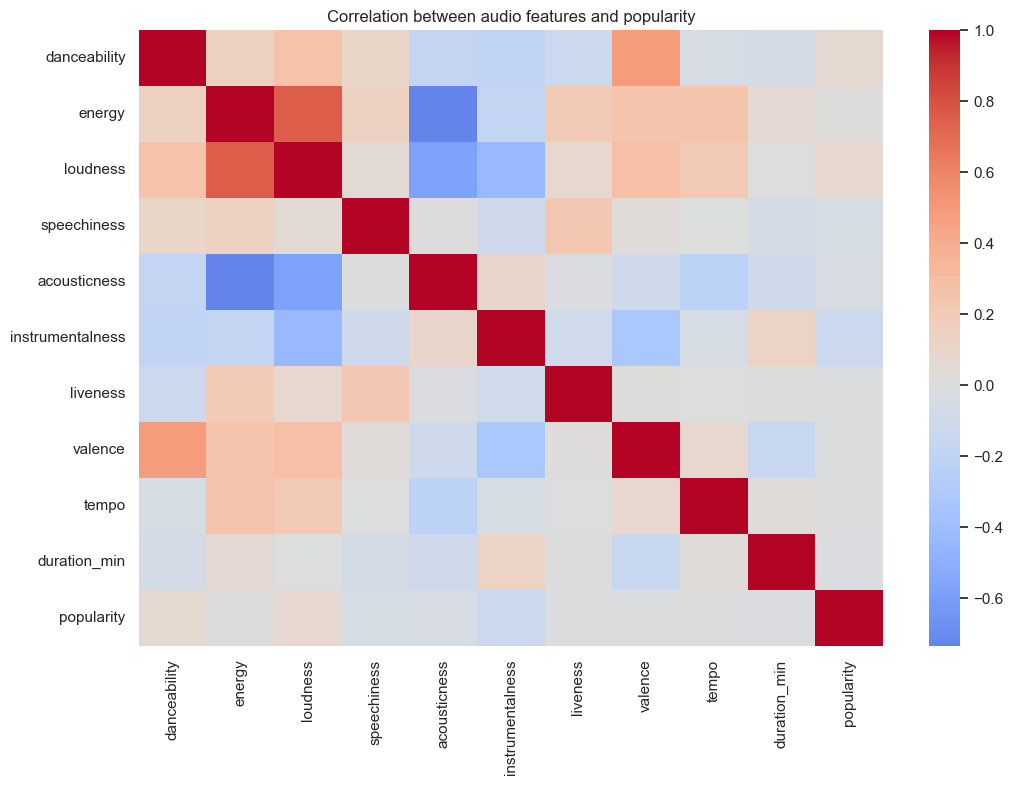

In [10]:
# =========================
# CELL 6: CORRELATION MATRIX
# =========================
# Fråga:
# Finns det enkla linjära samband mellan audio features och popularity?

corr_cols = audio_features + ["popularity"]

plt.figure(figsize=(12, 8))
sns.heatmap(
    df_model[corr_cols].corr(),
    annot=False,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation between audio features and popularity")
plt.show()

In [11]:
# =========================
# CELL 7.0: CREATE HIT MATRIX GROUPS
# =========================
# Denna cell MÅSTE köras innan:
# - Hit Matrix
# - Interactive 3D Hit Matrix
# - UMAP med hit_matrix_group

from pathlib import Path
import numpy as np

# Skapa results-mapp
results_path = project_folder / "results"
results_path.mkdir(exist_ok=True)

# Gränser
energy_limit = df_model["energy"].median()
popularity_limit = 70

# Skapa fyrfältsgrupper
def hit_matrix_group(row):
    if row["energy"] >= energy_limit and row["popularity"] >= popularity_limit:
        return "High energy + high popularity"
    elif row["energy"] >= energy_limit and row["popularity"] < popularity_limit:
        return "High energy + low popularity"
    elif row["energy"] < energy_limit and row["popularity"] >= popularity_limit:
        return "Low energy + high popularity"
    else:
        return "Low energy + low popularity"

df_model["hit_matrix_group"] = df_model.apply(hit_matrix_group, axis=1)

# Kontrollera att kolumnen finns
df_model[["energy", "popularity", "hit_matrix_group"]].head()

,energy,popularity,hit_matrix_group
0,0.4610,73,Low energy + high popularity
1,0.1660,55,Low energy + low popularity
2,0.3590,57,Low energy + low popularity
3,0.0596,71,Low energy + high popularity
4,0.4430,82,Low energy + high popularity


In [12]:
# =========================
# CELL 7.0: PREPARE GENRE / DUPLICATE DATA
# =========================

duplicate_tracks = df_dup[df_dup.duplicated(subset=["track_id"], keep=False)].copy()

genre_count_per_track = (
    duplicate_tracks
    .groupby(["track_id", "artists", "track_name"])
    .agg(
        number_of_genres=("track_genre", "nunique"),
        mean_popularity=("popularity", "mean"),
        max_popularity=("popularity", "max"),
        genres=("track_genre", lambda x: ", ".join(sorted(x.unique())))
    )
    .reset_index()
    .sort_values("number_of_genres", ascending=False)
)

print("Duplicate track rows:", duplicate_tracks.shape)
print("Tracks appearing in multiple genres:", genre_count_per_track.shape)

genre_count_per_track.head()

Duplicate track rows: (40900, 21)
Tracks appearing in multiple genres: (16641, 7)


,track_id,artists,track_name,number_of_genres,mean_popularity,max_popularity,genres
13819,6S3JlDAGk3uu3NtZbPnuhS,Badfinger,Baby Blue - Remastered 2010,9,67.0,67,"blues, country, folk, j-pop, j-rock, power-pop..."
5866,2kkvB3RNRzwjFdGhaUA0tz,Derek & The Dominos,Layla,8,74.0,74,"blues, british, country, folk, hard-rock, psyc..."
4797,2Ey6v4Sekh3Z0RUSISRosD,Derek & The Dominos,Layla,8,0.0,0,"blues, british, country, folk, hard-rock, psyc..."
6627,36NwMJRaCy7x77xYGJiG2M,Allman Brothers Band,Midnight Rider,7,1.0,1,"blues, country, folk, hard-rock, j-rock, singe..."
16415,7tbzfR8ZvZzJEzy6v0d6el,Ritviz,Liggi,7,68.0,68,"edm, hip-hop, indian, indie, indie-pop, pop, p..."


In [13]:
# =========================
# CELL 7: FEATURES MOST RELATED TO POPULARITY
# =========================
# Här sorterar vi korrelationerna mot popularity.
# Detta hjälper oss att se om någon enskild variabel verkar viktig.

pop_corr = (
    df_model[corr_cols]
    .corr()["popularity"]
    .sort_values(ascending=False)
)

pop_corr

popularity          1.000000
loudness            0.073262
danceability        0.065965
energy              0.014449
tempo               0.008790
valence            -0.010934
liveness           -0.014269
duration_min       -0.023107
acousticness       -0.038991
speechiness        -0.046861
instrumentalness   -0.128516
Name: popularity, dtype: float64

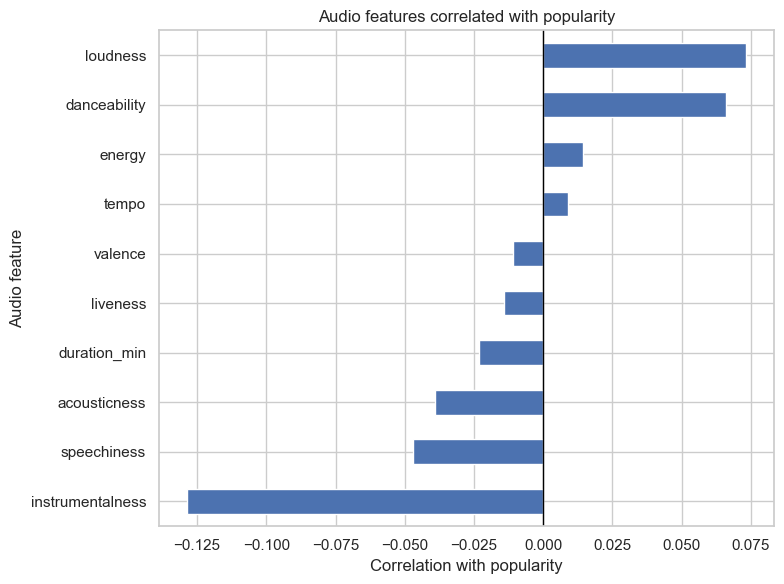

In [14]:
# =========================
# CELL 7.1: VISUALIZE CORRELATION WITH POPULARITY
# =========================
# Syfte:
# Vi vill visa vilka ljudvariabler som har starkast linjärt samband med popularity.
#
# Viktigt:
# Detta visar INTE orsakssamband.
# Det visar bara om variabler tenderar att öka/minska tillsammans med popularity.

pop_corr_no_self = pop_corr.drop("popularity").sort_values()

plt.figure(figsize=(8, 6))
pop_corr_no_self.plot(kind="barh")

plt.title("Audio features correlated with popularity")
plt.xlabel("Correlation with popularity")
plt.ylabel("Audio feature")
plt.axvline(0, color="black", linewidth=1)

plt.tight_layout()
plt.show()

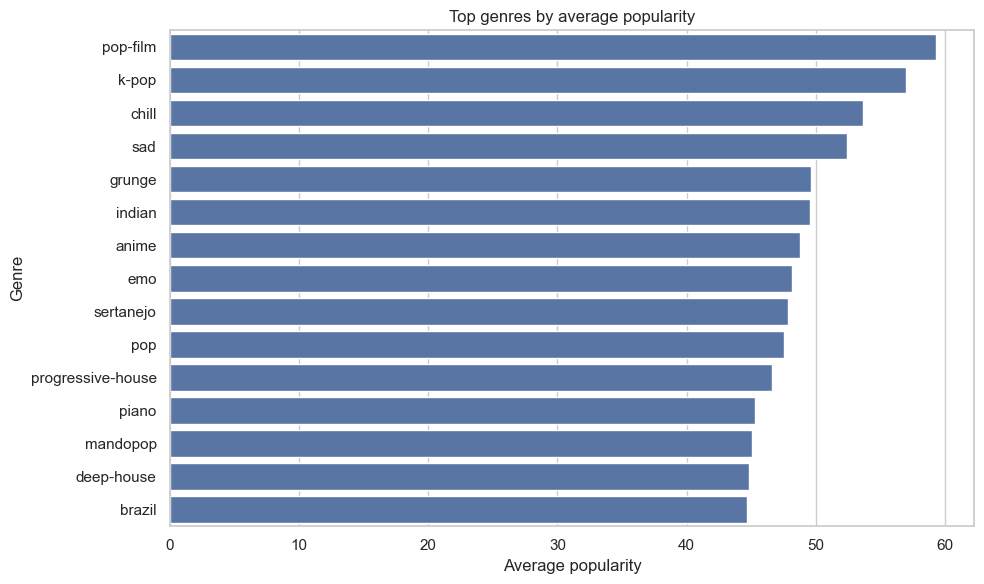

,track_genre,mean_popularity,median_popularity,number_of_songs
81,pop-film,59.283000,60.0,1000
65,k-pop,56.952953,60.0,999
15,chill,53.651000,57.0,1000
94,sad,52.379000,54.0,1000
44,grunge,49.594000,55.0,1000
55,indian,49.539000,49.0,1000
5,anime,48.772000,50.0,1000
33,emo,48.128000,51.0,1000
97,sertanejo,47.866000,47.0,1000
80,pop,47.576000,66.0,1000


In [15]:
# =========================
# CELL 7.2: MOST POPULAR GENRES
# =========================
# Syfte:
# Skivbolaget vill veta vilka genres som i genomsnitt verkar mest populära.
#
# Här använder vi datasetet med dubbletter eftersom genre är viktig.
# Samma låt kan förekomma i flera genres, och det är relevant för genreanalys.

genre_popularity = (
    df_dup
    .groupby("track_genre")
    .agg(
        mean_popularity=("popularity", "mean"),
        median_popularity=("popularity", "median"),
        number_of_songs=("track_id", "count")
    )
    .reset_index()
)

# Vi filtrerar bort väldigt små genres om det finns sådana.
genre_popularity_filtered = genre_popularity[genre_popularity["number_of_songs"] >= 100]

top_genres = genre_popularity_filtered.sort_values(
    "mean_popularity",
    ascending=False
).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_genres,
    x="mean_popularity",
    y="track_genre"
)

plt.title("Top genres by average popularity")
plt.xlabel("Average popularity")
plt.ylabel("Genre")

plt.tight_layout()
plt.show()

top_genres

In [16]:
# =========================
# CELL 7.2a: ALL GENRES
# =========================

all_genres = sorted(df_dup["track_genre"].unique())

print(f"Antal genrer: {len(all_genres)}")
all_genres[:50]  # visa första 50

Antal genrer: 114


['acoustic',
 'afrobeat',
 'alt-rock',
 'alternative',
 'ambient',
 'anime',
 'black-metal',
 'bluegrass',
 'blues',
 'brazil',
 'breakbeat',
 'british',
 'cantopop',
 'chicago-house',
 'children',
 'chill',
 'classical',
 'club',
 'comedy',
 'country',
 'dance',
 'dancehall',
 'death-metal',
 'deep-house',
 'detroit-techno',
 'disco',
 'disney',
 'drum-and-bass',
 'dub',
 'dubstep',
 'edm',
 'electro',
 'electronic',
 'emo',
 'folk',
 'forro',
 'french',
 'funk',
 'garage',
 'german',
 'gospel',
 'goth',
 'grindcore',
 'groove',
 'grunge',
 'guitar',
 'happy',
 'hard-rock',
 'hardcore',
 'hardstyle']

In [17]:
# =========================
# CELL 7.2b: CHECK SPECIFIC GENRES
# =========================

genres_of_interest = ["hip-hop", "pop", "techno", "trance", "house", "dance", "electronic"]

df_dup[df_dup["track_genre"].isin(genres_of_interest)]["track_genre"].value_counts()

track_genre
dance         1000
electronic    1000
hip-hop       1000
house         1000
pop           1000
techno        1000
trance        1000
Name: count, dtype: int64

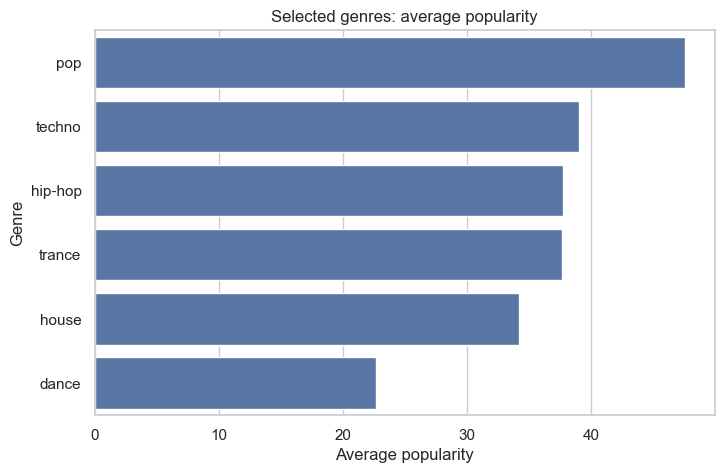

,track_genre,mean_popularity
3,pop,47.576
4,techno,39.042
1,hip-hop,37.759
5,trance,37.635
2,house,34.156
0,dance,22.690


In [18]:
# =========================
# CELL 7.2c: POPULARITY FOR SELECTED GENRES
# =========================

selected_genres = ["hip-hop", "pop", "techno", "trance", "house", "dance"]

genre_subset = (
    df_dup[df_dup["track_genre"].isin(selected_genres)]
    .groupby("track_genre")
    .agg(mean_popularity=("popularity", "mean"))
    .reset_index()
    .sort_values("mean_popularity", ascending=False)
)

plt.figure(figsize=(8, 5))
sns.barplot(data=genre_subset, x="mean_popularity", y="track_genre")

plt.title("Selected genres: average popularity")
plt.xlabel("Average popularity")
plt.ylabel("Genre")

plt.show()

genre_subset

In [19]:
# =========================
# CELL 7.2a: CHECK DATASETS
# =========================
# Syfte:
# Säkerställa att vi använder rätt dataset.
#
# df_dup = datasetet där genre-dubbletter är kvar.
# Det är bäst för genreanalys eftersom samma låt kan tillhöra flera genres.

print("df_dup shape:", df_dup.shape)
print("Columns:", df_dup.columns.tolist())

df_dup[["track_id", "track_name", "artists", "track_genre", "popularity"]].head()

df_dup shape: (113999, 21)
Columns: ['track_id', 'artists', 'album_name', 'track_name', 'popularity', 'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'track_genre', 'duration_min']


,track_id,track_name,artists,track_genre,popularity
0,5SuOikwiRyPMVoIQDJUgSV,Comedy,Gen Hoshino,acoustic,73
1,4qPNDBW1i3p13qLCt0Ki3A,Ghost - Acoustic,Ben Woodward,acoustic,55
2,1iJBSr7s7jYXzM8EGcbK5b,To Begin Again,Ingrid Michaelson;ZAYN,acoustic,57
3,6lfxq3CG4xtTiEg7opyCyx,Can't Help Falling In Love,Kina Grannis,acoustic,71
4,5vjLSffimiIP26QG5WcN2K,Hold On,Chord Overstreet,acoustic,82


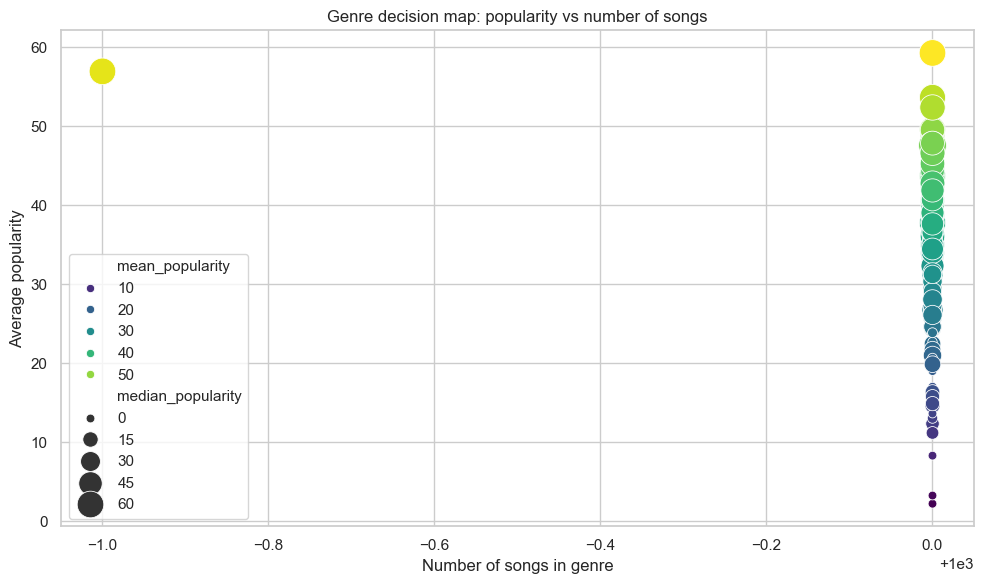

,track_genre,mean_popularity,median_popularity,number_of_songs,max_popularity
81,pop-film,59.283000,60.0,1000,80
65,k-pop,56.952953,60.0,999,88
15,chill,53.651000,57.0,1000,93
94,sad,52.379000,54.0,1000,83
44,grunge,49.594000,55.0,1000,85
55,indian,49.539000,49.0,1000,88
5,anime,48.772000,50.0,1000,83
33,emo,48.128000,51.0,1000,87
97,sertanejo,47.866000,47.0,1000,63
80,pop,47.576000,66.0,1000,100


In [20]:
# =========================
# CELL 7.2b: GENRE POPULARITY VS NUMBER OF SONGS
# =========================
# Fråga:
# Finns det genres som både har många låtar och hög popularitet?
#
# Varför:
# En genre med hög popularity men få låtar kan vara osäker.
# En genre med många låtar och hög popularity är mer stabilt intressant för skivbolaget.

genre_popularity = (
    df_dup
    .groupby("track_genre")
    .agg(
        mean_popularity=("popularity", "mean"),
        median_popularity=("popularity", "median"),
        number_of_songs=("track_id", "count"),
        max_popularity=("popularity", "max")
    )
    .reset_index()
)

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=genre_popularity,
    x="number_of_songs",
    y="mean_popularity",
    size="median_popularity",
    hue="mean_popularity",
    sizes=(40, 400),
    palette="viridis"
)

plt.title("Genre decision map: popularity vs number of songs")
plt.xlabel("Number of songs in genre")
plt.ylabel("Average popularity")
plt.tight_layout()
plt.show()

genre_popularity.sort_values("mean_popularity", ascending=False).head(20)

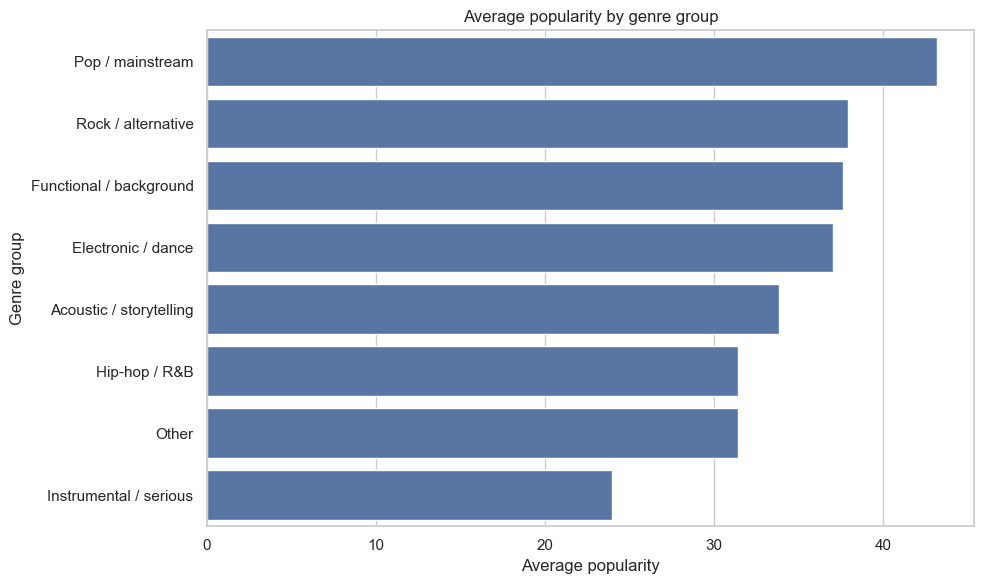

,genre_group,mean_popularity,median_popularity,number_of_songs,max_popularity
6,Pop / mainstream,43.204023,48.0,8999,100
7,Rock / alternative,37.884833,42.0,6000,96
2,Functional / background,37.617200,39.0,5000,93
1,Electronic / dance,37.006625,45.0,8000,100
0,Acoustic / storytelling,33.832500,40.0,4000,90
3,Hip-hop / R&B,31.413667,41.0,3000,99
5,Other,31.413487,31.0,76000,98
4,Instrumental / serious,23.985333,10.0,3000,96


In [21]:
# =========================
# CELL 7.2c: GROUP GENRES INTO STORY GROUPS
# =========================
# Syfte:
# Datasetet har många små genres.
# För presentation blir det tydligare att samla dem i större musikvärldar.

def genre_group(genre):
    genre = str(genre).lower()

    if "pop" in genre or genre in ["k-pop", "j-pop", "mandopop"]:
        return "Pop / mainstream"

    elif "hip-hop" in genre or "r-n-b" in genre or "soul" in genre:
        return "Hip-hop / R&B"

    elif genre in ["dance", "edm", "electro", "house", "deep-house", "progressive-house", "techno", "trance"]:
        return "Electronic / dance"

    elif genre in ["rock", "alt-rock", "hard-rock", "punk", "grunge", "metal"]:
        return "Rock / alternative"

    elif genre in ["acoustic", "singer-songwriter", "folk", "country"]:
        return "Acoustic / storytelling"

    elif genre in ["sleep", "ambient", "study", "chill", "new-age"]:
        return "Functional / background"

    elif genre in ["classical", "piano", "jazz"]:
        return "Instrumental / serious"

    else:
        return "Other"

df_dup["genre_group"] = df_dup["track_genre"].apply(genre_group)

genre_group_stats = (
    df_dup
    .groupby("genre_group")
    .agg(
        mean_popularity=("popularity", "mean"),
        median_popularity=("popularity", "median"),
        number_of_songs=("track_id", "count"),
        max_popularity=("popularity", "max")
    )
    .reset_index()
    .sort_values("mean_popularity", ascending=False)
)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=genre_group_stats,
    x="mean_popularity",
    y="genre_group"
)

plt.title("Average popularity by genre group")
plt.xlabel("Average popularity")
plt.ylabel("Genre group")
plt.tight_layout()
plt.show()

genre_group_stats

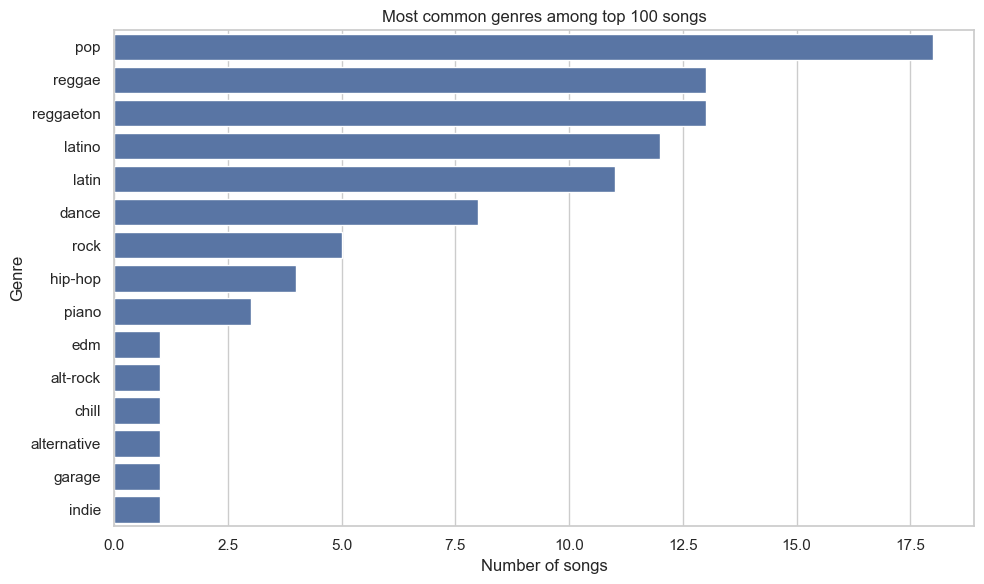

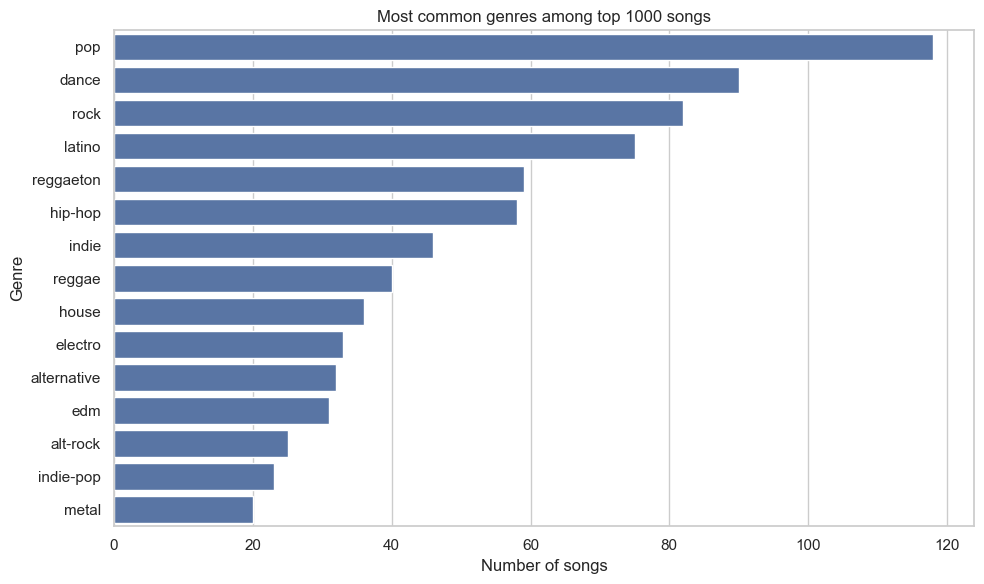

,track_genre,count
0,pop,18
1,reggae,13
2,reggaeton,13
3,latino,12
4,latin,11
5,dance,8
6,rock,5
7,hip-hop,4
8,piano,3
9,edm,1


,track_genre,count
0,pop,118
1,dance,90
2,rock,82
3,latino,75
4,reggaeton,59
5,hip-hop,58
6,indie,46
7,reggae,40
8,house,36
9,electro,33


In [22]:
# =========================
# CELL 7.2d: GENRES AMONG TOP SONGS
# =========================
# Syfte:
# Snitt kan bli missvisande om en genre har många lågpopulära låtar.
# Därför tittar vi separat på topp 100 och topp 1000 låtar.

top_100 = df_dup.sort_values("popularity", ascending=False).head(100)
top_1000 = df_dup.sort_values("popularity", ascending=False).head(1000)

top_100_genres = (
    top_100["track_genre"]
    .value_counts()
    .head(15)
    .reset_index()
)

top_100_genres.columns = ["track_genre", "count"]

top_1000_genres = (
    top_1000["track_genre"]
    .value_counts()
    .head(15)
    .reset_index()
)

top_1000_genres.columns = ["track_genre", "count"]

plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_100_genres,
    x="count",
    y="track_genre"
)

plt.title("Most common genres among top 100 songs")
plt.xlabel("Number of songs")
plt.ylabel("Genre")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_1000_genres,
    x="count",
    y="track_genre"
)

plt.title("Most common genres among top 1000 songs")
plt.xlabel("Number of songs")
plt.ylabel("Genre")
plt.tight_layout()
plt.show()

display(top_100_genres)
display(top_1000_genres)

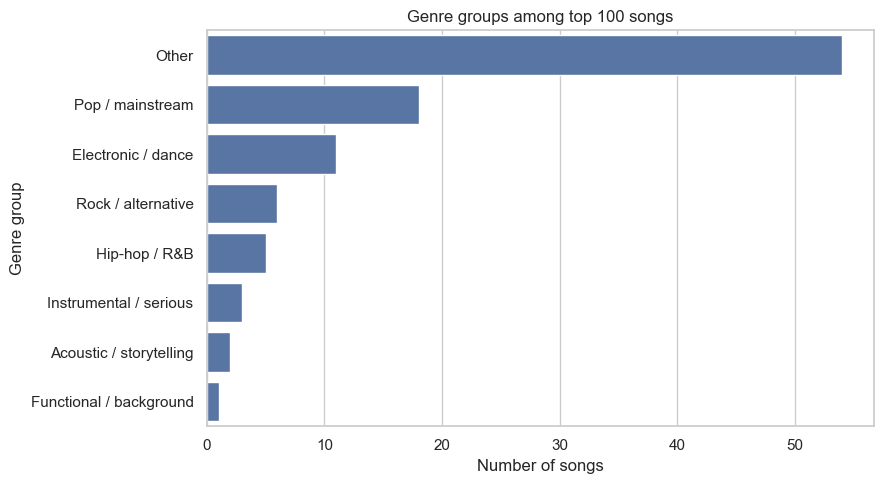

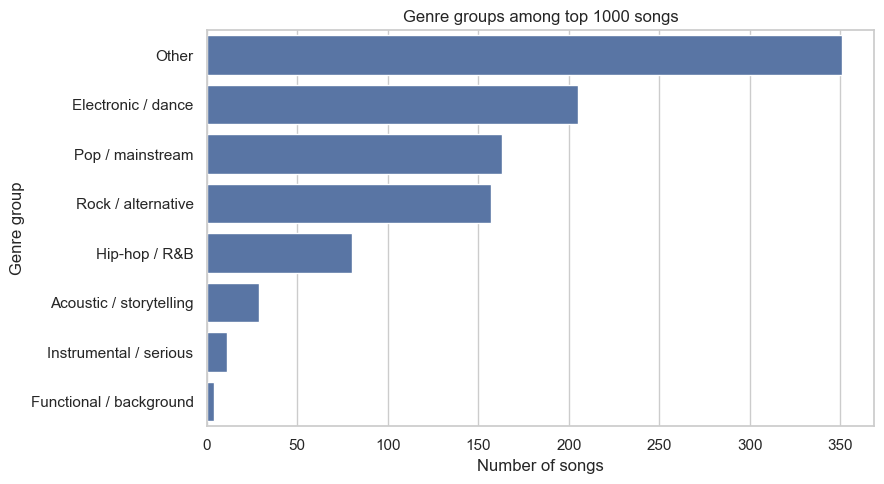

,genre_group,count
0,Other,54
1,Pop / mainstream,18
2,Electronic / dance,11
3,Rock / alternative,6
4,Hip-hop / R&B,5
5,Instrumental / serious,3
6,Acoustic / storytelling,2
7,Functional / background,1


,genre_group,count
0,Other,351
1,Electronic / dance,205
2,Pop / mainstream,163
3,Rock / alternative,157
4,Hip-hop / R&B,80
5,Acoustic / storytelling,29
6,Instrumental / serious,11
7,Functional / background,4


In [23]:
# =========================
# CELL 7.2e: GENRE GROUPS AMONG TOP SONGS
# =========================
# Syfte:
# Samma sak som ovan, men med våra större genregrupper.
# Detta är lättare att presentera för ett skivbolag.

top_100 = top_100.copy()
top_1000 = top_1000.copy()

top_100["genre_group"] = top_100["track_genre"].apply(genre_group)
top_1000["genre_group"] = top_1000["track_genre"].apply(genre_group)

top_100_group_counts = (
    top_100["genre_group"]
    .value_counts()
    .reset_index()
)

top_100_group_counts.columns = ["genre_group", "count"]

top_1000_group_counts = (
    top_1000["genre_group"]
    .value_counts()
    .reset_index()
)

top_1000_group_counts.columns = ["genre_group", "count"]

plt.figure(figsize=(9, 5))
sns.barplot(
    data=top_100_group_counts,
    x="count",
    y="genre_group"
)

plt.title("Genre groups among top 100 songs")
plt.xlabel("Number of songs")
plt.ylabel("Genre group")
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 5))
sns.barplot(
    data=top_1000_group_counts,
    x="count",
    y="genre_group"
)

plt.title("Genre groups among top 1000 songs")
plt.xlabel("Number of songs")
plt.ylabel("Genre group")
plt.tight_layout()
plt.show()

display(top_100_group_counts)
display(top_1000_group_counts)

In [24]:
# =========================
# CELL 7.2f: AUDIO PROFILE OF TOP SONGS
# =========================
# Fråga:
# Vad kännetecknar topp 100 och topp 1000 jämfört med resten?
#
# Detta är väldigt relevant för storyn:
# "Vad verkar en hit-låt innehålla?"

audio_features = [
    "danceability",
    "energy",
    "loudness",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo",
    "duration_min"
]

df_compare = df_dup.copy()

df_compare["song_group"] = "Other songs"

top_100_ids = top_100["track_id"]
top_1000_ids = top_1000["track_id"]

df_compare.loc[df_compare["track_id"].isin(top_1000_ids), "song_group"] = "Top 1000"
df_compare.loc[df_compare["track_id"].isin(top_100_ids), "song_group"] = "Top 100"

audio_profile = (
    df_compare
    .groupby("song_group")[audio_features]
    .mean()
    .T
)

audio_profile = audio_profile[["Other songs", "Top 1000", "Top 100"]]

audio_profile

song_group,Other songs,Top 1000,Top 100
danceability,0.566011,0.646922,0.700544
energy,0.640970,0.687376,0.674922
loudness,-8.279377,-6.050962,-6.029330
speechiness,0.084686,0.079490,0.095169
acousticness,0.316129,0.177977,0.225943
instrumentalness,0.157262,0.027551,0.002174
liveness,0.213969,0.167716,0.177517
valence,0.473707,0.521467,0.434533
tempo,122.345241,119.132228,119.513553
duration_min,3.802823,3.563207,3.441972


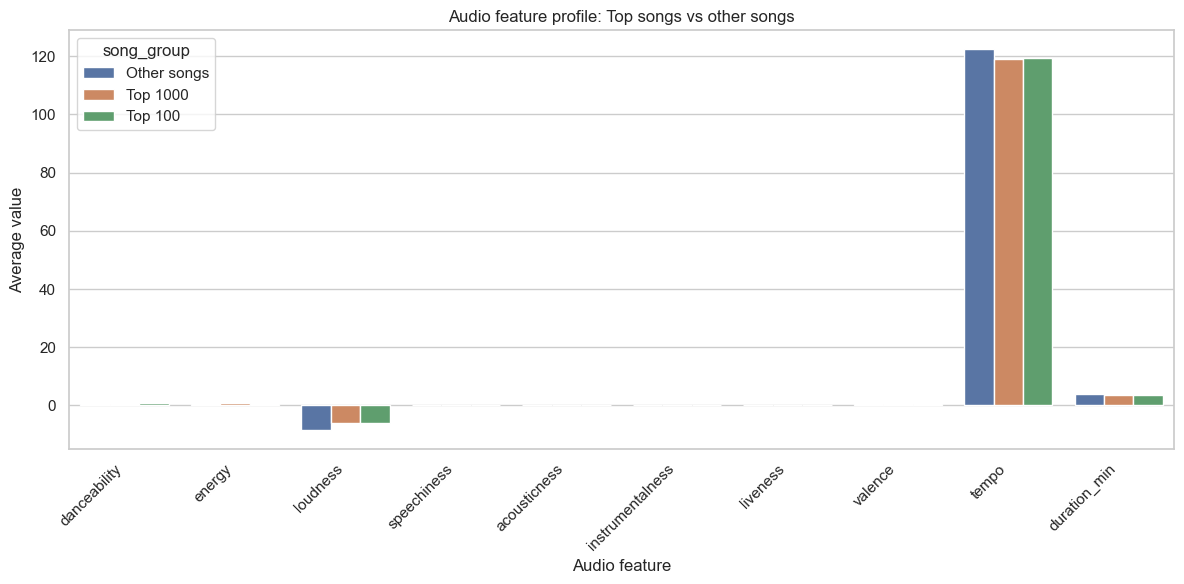

In [25]:
# =========================
# CELL 7.2g: VISUALIZE AUDIO PROFILE OF TOP SONGS
# =========================

audio_profile_plot = audio_profile.reset_index().melt(
    id_vars="index",
    var_name="song_group",
    value_name="mean_value"
)

audio_profile_plot = audio_profile_plot.rename(columns={"index": "audio_feature"})

plt.figure(figsize=(12, 6))
sns.barplot(
    data=audio_profile_plot,
    x="audio_feature",
    y="mean_value",
    hue="song_group"
)

plt.title("Audio feature profile: Top songs vs other songs")
plt.xlabel("Audio feature")
plt.ylabel("Average value")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

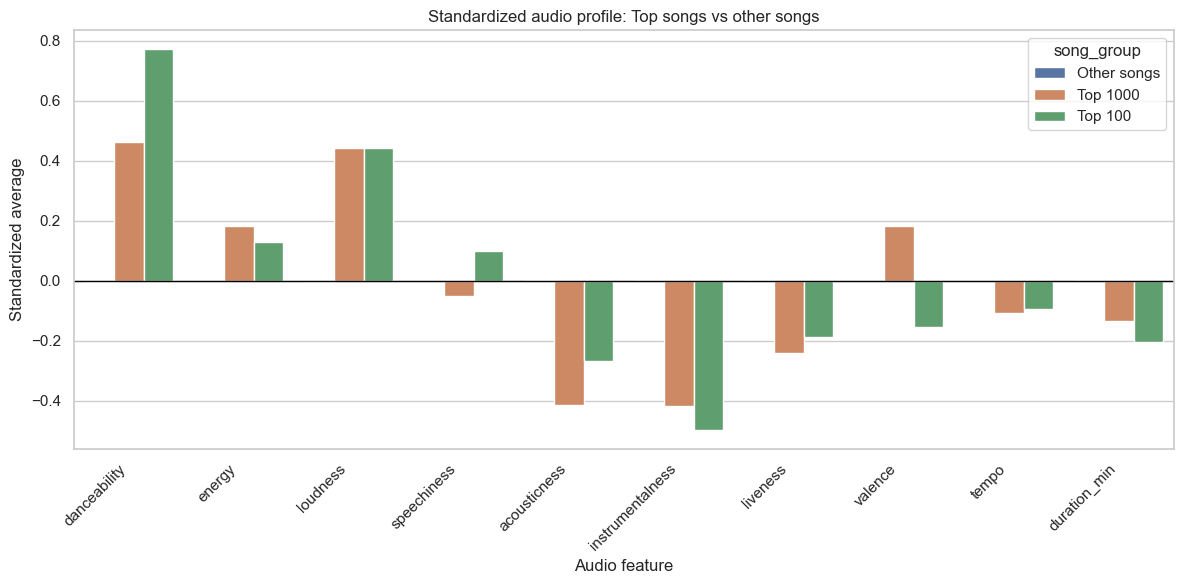

song_group,Other songs,Top 1000,Top 100
danceability,-0.004573,0.464256,0.771329
energy,-0.001648,0.183438,0.130881
loudness,-0.004097,0.443113,0.442671
speechiness,0.000320,-0.049121,0.098336
acousticness,0.003687,-0.413228,-0.266936
instrumentalness,0.003929,-0.417146,-0.495952
liveness,0.002166,-0.239273,-0.187992
valence,-0.001381,0.182745,-0.155257
tempo,0.000981,-0.107371,-0.094512
duration_min,0.001297,-0.133434,-0.203097


In [26]:
# =========================
# CELL 7.2h: STANDARDIZED HIT PROFILE
# =========================
# Syfte:
# Eftersom variablerna har olika skalor standardiserar vi skillnaden.
#
# Då kan vi se:
# Vilka egenskaper är högre/lägre hos topplåtar jämfört med övriga?

from sklearn.preprocessing import StandardScaler

profile_df = df_compare[audio_features + ["song_group"]].dropna().copy()

scaler_profile = StandardScaler()
profile_scaled = scaler_profile.fit_transform(profile_df[audio_features])

profile_scaled_df = pd.DataFrame(profile_scaled, columns=audio_features)
profile_scaled_df["song_group"] = profile_df["song_group"].values

standardized_profile = (
    profile_scaled_df
    .groupby("song_group")[audio_features]
    .mean()
    .T
)

standardized_profile = standardized_profile[["Other songs", "Top 1000", "Top 100"]]

standardized_plot = standardized_profile.reset_index().melt(
    id_vars="index",
    var_name="song_group",
    value_name="standardized_mean"
)

standardized_plot = standardized_plot.rename(columns={"index": "audio_feature"})

plt.figure(figsize=(12, 6))
sns.barplot(
    data=standardized_plot,
    x="audio_feature",
    y="standardized_mean",
    hue="song_group"
)

plt.axhline(0, color="black", linewidth=1)
plt.title("Standardized audio profile: Top songs vs other songs")
plt.xlabel("Audio feature")
plt.ylabel("Standardized average")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

standardized_profile

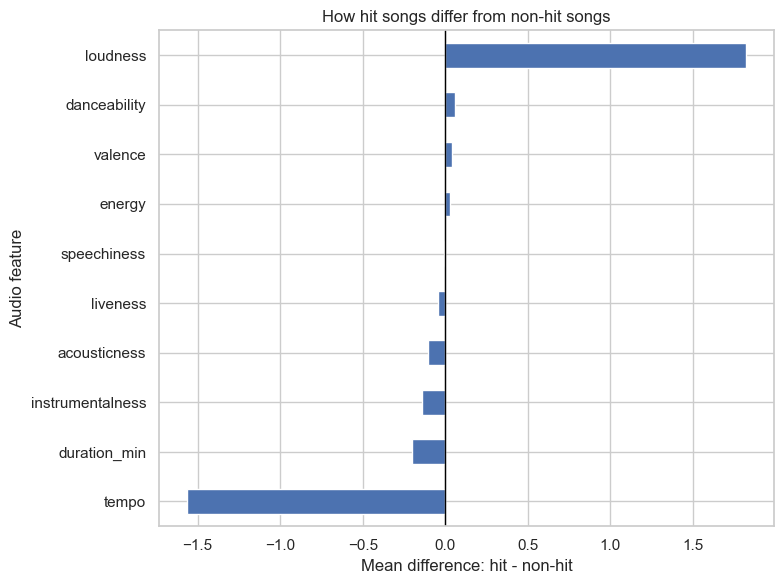

,non_hit,hit,difference_hit_minus_non_hit
tempo,122.326545,120.763841,-1.562704
duration_min,3.827803,3.625462,-0.202341
instrumentalness,0.177598,0.033682,-0.143916
acousticness,0.331555,0.229327,-0.102228
liveness,0.218097,0.173866,-0.044231
speechiness,0.087855,0.080418,-0.007437
energy,0.634304,0.664439,0.030134
valence,0.468797,0.511818,0.043021
danceability,0.561008,0.622480,0.061472
loudness,-8.538704,-6.716825,1.821880


In [27]:
# =========================
# CELL 7.3: HIT SONG PROFILE
# =========================
# Syfte:
# Vi skapar en enkel kategori:
# - hit = popularity >= 70
# - non-hit = popularity < 70
#
# Detta är inte unsupervised learning, men det är bra EDA för presentationen.
# Det hjälper oss jämföra ljudprofilen hos populära och mindre populära låtar.

df_model["is_hit"] = df_model["popularity"] >= 70

hit_profile = (
    df_model
    .groupby("is_hit")[audio_features]
    .mean()
    .T
)

hit_profile.columns = ["non_hit", "hit"]
hit_profile["difference_hit_minus_non_hit"] = hit_profile["hit"] - hit_profile["non_hit"]

hit_profile_sorted = hit_profile.sort_values("difference_hit_minus_non_hit")

plt.figure(figsize=(8, 6))
hit_profile_sorted["difference_hit_minus_non_hit"].plot(kind="barh")

plt.title("How hit songs differ from non-hit songs")
plt.xlabel("Mean difference: hit - non-hit")
plt.ylabel("Audio feature")
plt.axvline(0, color="black", linewidth=1)

plt.tight_layout()
plt.show()

hit_profile_sorted

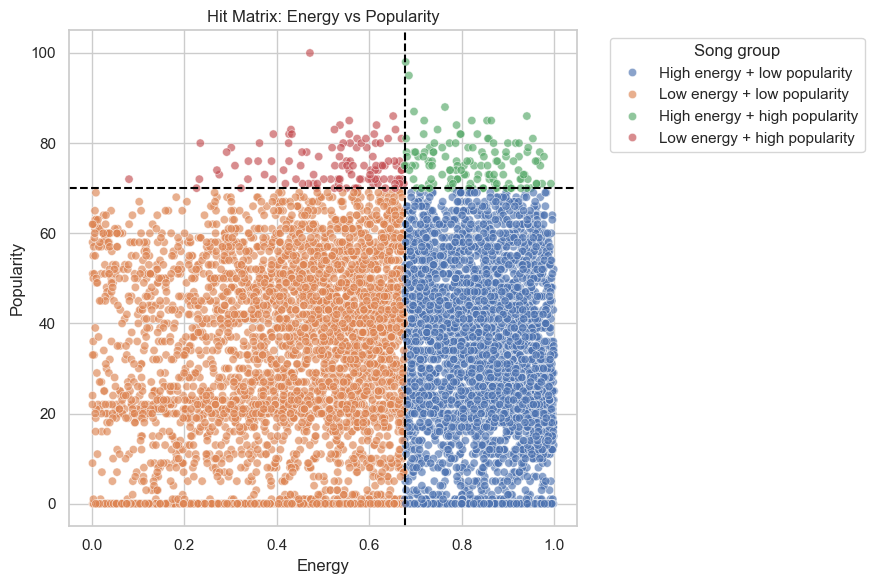

In [28]:
# =========================
# CELL 7.4: HIT MATRIX - CLEAN VERSION
# =========================

df_sample = df_model.sample(n=8000, random_state=42)

plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=df_sample,
    x="energy",
    y="popularity",
    hue="hit_matrix_group",
    alpha=0.65
)

plt.axhline(70, color="black", linestyle="--")
plt.axvline(df_model["energy"].median(), color="black", linestyle="--")

plt.title("Hit Matrix: Energy vs Popularity")
plt.xlabel("Energy")
plt.ylabel("Popularity")
plt.legend(title="Song group", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

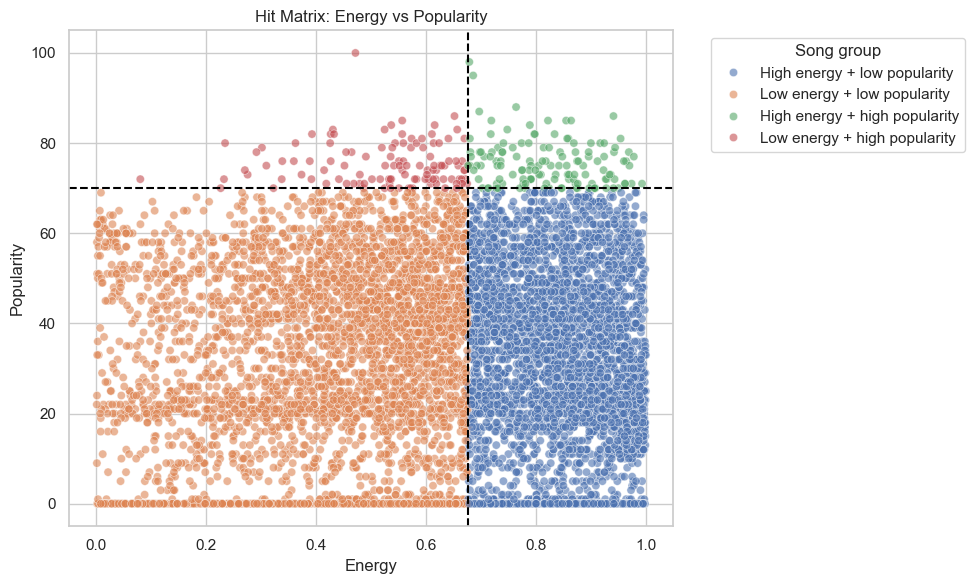

In [29]:
# =========================
# CELL 7.5: CLEAN HIT MATRIX WITH 4 GROUPS
# =========================
# Syfte:
# Vi delar upp låtar i fyra tydliga grupper:
# 1. High energy + high popularity = tydliga hits
# 2. High energy + low popularity = energiska men inte populära
# 3. Low energy + high popularity = oväntade hits
# 4. Low energy + low popularity = låg energi och låg popularitet

energy_limit = df_model["energy"].median()
popularity_limit = 70

def hit_matrix_group(row):
    if row["energy"] >= energy_limit and row["popularity"] >= popularity_limit:
        return "High energy + high popularity"
    elif row["energy"] >= energy_limit and row["popularity"] < popularity_limit:
        return "High energy + low popularity"
    elif row["energy"] < energy_limit and row["popularity"] >= popularity_limit:
        return "Low energy + high popularity"
    else:
        return "Low energy + low popularity"

df_model["hit_matrix_group"] = df_model.apply(hit_matrix_group, axis=1)

# Vi tar ett sample för att grafen inte ska bli överfull
df_sample = df_model.sample(n=8000, random_state=42)

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_sample,
    x="energy",
    y="popularity",
    hue="hit_matrix_group",
    alpha=0.6
)

plt.axhline(popularity_limit, color="black", linestyle="--")
plt.axvline(energy_limit, color="black", linestyle="--")

plt.title("Hit Matrix: Energy vs Popularity")
plt.xlabel("Energy")
plt.ylabel("Popularity")
plt.legend(title="Song group", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

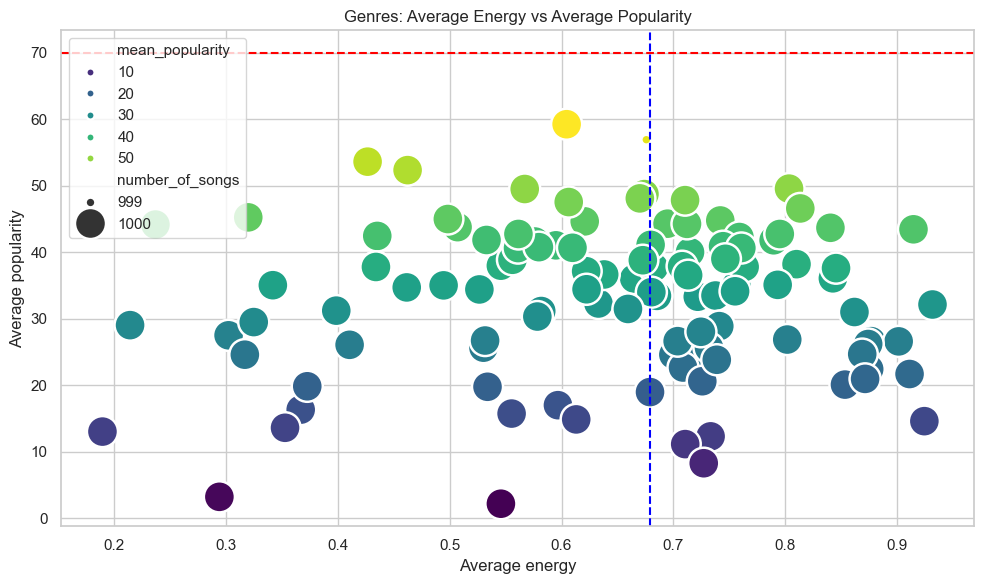

,track_genre,mean_energy,mean_popularity,number_of_songs
81,pop-film,0.604562,59.283000,1000
65,k-pop,0.675747,56.952953,999
15,chill,0.426723,53.651000,1000
94,sad,0.462470,52.379000,1000
44,grunge,0.803290,49.594000,1000
55,indian,0.567121,49.539000,1000
5,anime,0.674108,48.772000,1000
33,emo,0.669967,48.128000,1000
97,sertanejo,0.710391,47.866000,1000
80,pop,0.606437,47.576000,1000


In [30]:
# =========================
# CELL 7.6: AGGREGATED HIT MATRIX
# =========================
# Syfte:
# Istället för att visa varje låt visar vi medelvärde per genre.
# Då blir grafen mycket lättare att läsa.

genre_hit_matrix = (
    df_dup
    .groupby("track_genre")
    .agg(
        mean_energy=("energy", "mean"),
        mean_popularity=("popularity", "mean"),
        number_of_songs=("track_id", "count")
    )
    .reset_index()
)

genre_hit_matrix = genre_hit_matrix[genre_hit_matrix["number_of_songs"] >= 100]

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=genre_hit_matrix,
    x="mean_energy",
    y="mean_popularity",
    size="number_of_songs",
    hue="mean_popularity",
    sizes=(50, 500),
    palette="viridis"
)

plt.axhline(70, color="red", linestyle="--")
plt.axvline(genre_hit_matrix["mean_energy"].median(), color="blue", linestyle="--")

plt.title("Genres: Average Energy vs Average Popularity")
plt.xlabel("Average energy")
plt.ylabel("Average popularity")

plt.tight_layout()
plt.show()

genre_hit_matrix.sort_values("mean_popularity", ascending=False).head(20)

In [31]:
# =========================
# CELL 7.7: INTERACTIVE 3D HIT MATRIX
# =========================
# Syfte:
# 3D-graf där vi kan rotera och utforska:
# energy, danceability och popularity.

import plotly.express as px

df_3d = df_model.sample(n=8000, random_state=42)

fig = px.scatter_3d(
    df_3d,
    x="energy",
    y="danceability",
    z="popularity",
    color="hit_matrix_group",
    hover_data=["track_name", "artists", "track_genre"],
    title="Interactive 3D: Energy, Danceability and Popularity"
)

fig.show()

# Sparar som separat HTML-fil som kan öppnas i webbläsaren
fig.write_html("../results/interactive_3d_hit_matrix.html")

In [63]:
# =========================
# CELL 7.7: INTERACTIVE 3D HIT MATRIX + LOUDNESS
# =========================
# Syfte:
# 3D-graf där vi kan rotera och utforska:
# energy, danceability, popularity
#
# Loudness läggs till som punktstorlek och hover-info.
# Större punkt = högre loudness.

import plotly.express as px
from pathlib import Path

results_path = project_folder / "results"
results_path.mkdir(exist_ok=True)

df_3d = df_model.sample(n=8000, random_state=42).copy()

# Loudness är ofta negativt, t.ex. -20 till 0.
# Därför skapar vi en positiv version som kan användas som punktstorlek.
df_3d["loudness_size"] = df_3d["loudness"] - df_3d["loudness"].min() + 1

fig = px.scatter_3d(
    df_3d,
    x="energy",
    y="danceability",
    z="popularity",
    color="hit_matrix_group",
    size="loudness_size",
    size_max=12,
    hover_data=[
        "track_name",
        "artists",
        "track_genre",
        "energy",
        "danceability",
        "loudness",
        "popularity"
    ],
    title="Interactive 3D: Energy, Danceability, Popularity + Loudness"
)

fig.show(renderer="browser")

fig.write_html(results_path / "interactive_3d_hit_matrix_loudness.html")

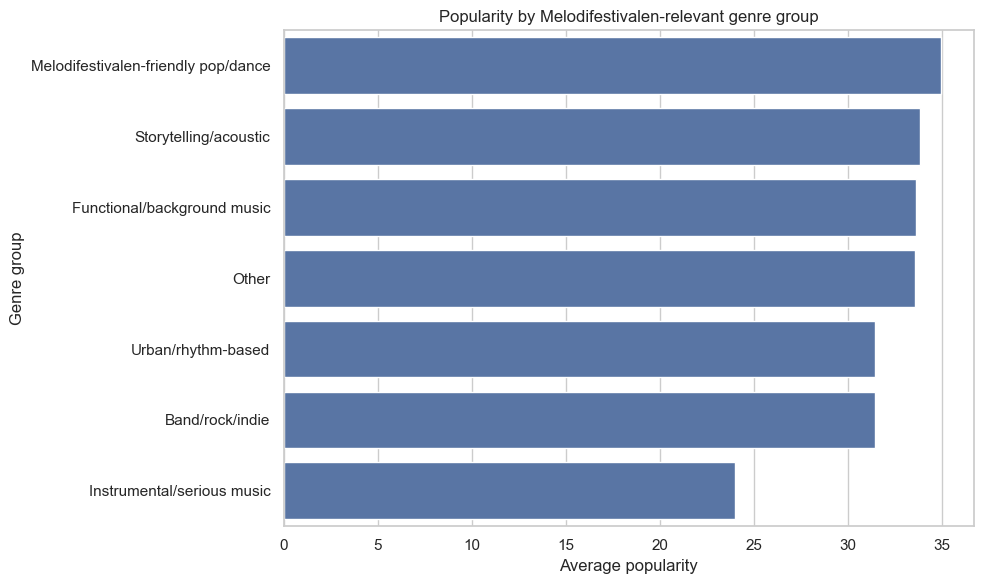

,genre_group,mean_popularity,median_popularity,number_of_songs
3,Melodifestivalen-friendly pop/dance,34.942200,37.0,5000
5,Storytelling/acoustic,33.832500,40.0,4000
1,Functional/background music,33.608750,34.0,4000
4,Other,33.572506,34.0,89999
6,Urban/rhythm-based,31.413667,41.0,3000
0,Band/rock/indie,31.405600,27.0,5000
2,Instrumental/serious music,23.985333,10.0,3000


In [64]:
# =========================
# CELL 7.8: MELODIFESTIVALEN GENRE GROUPS
# =========================
# Syfte:
# Vi grupperar genres i mer presentationvänliga kategorier.
# Detta är inte "facit", utan en analytisk förenkling för storyn.

def genre_group(genre):
    genre = str(genre).lower()
    
    if genre in ["pop", "dance", "edm", "electro", "club"]:
        return "Melodifestivalen-friendly pop/dance"
    elif genre in ["rock", "alt-rock", "indie", "punk", "power-pop"]:
        return "Band/rock/indie"
    elif genre in ["singer-songwriter", "folk", "acoustic", "country"]:
        return "Storytelling/acoustic"
    elif genre in ["sleep", "ambient", "study", "new-age"]:
        return "Functional/background music"
    elif genre in ["classical", "piano", "jazz"]:
        return "Instrumental/serious music"
    elif genre in ["hip-hop", "r-n-b", "soul"]:
        return "Urban/rhythm-based"
    else:
        return "Other"

df_dup["genre_group"] = df_dup["track_genre"].apply(genre_group)

genre_group_stats = (
    df_dup
    .groupby("genre_group")
    .agg(
        mean_popularity=("popularity", "mean"),
        median_popularity=("popularity", "median"),
        number_of_songs=("track_id", "count")
    )
    .reset_index()
    .sort_values("mean_popularity", ascending=False)
)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=genre_group_stats,
    x="mean_popularity",
    y="genre_group"
)

plt.title("Popularity by Melodifestivalen-relevant genre group")
plt.xlabel("Average popularity")
plt.ylabel("Genre group")

plt.tight_layout()
plt.show()

genre_group_stats

In [65]:
# =========================
# CELL 8: STANDARDIZE FEATURES
# =========================
# K-means, PCA och Isolation Forest påverkas av skala.
# Exempel: tempo har värden runt 100-200 medan danceability ligger 0-1.
# Därför standardiserar vi så att variablerna blir jämförbara.

X = df_model[audio_features].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=audio_features)

X_scaled_df.head()

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_min
0,0.643854,-0.681818,0.333868,0.488933,-0.874830,-0.534113,0.727821,0.932713,-1.156469,0.012717
1,-0.816749,-1.835421,-1.691345,-0.099681,1.762764,-0.534099,-0.594596,-0.774891,-1.507499,-0.712564
2,-0.714050,-1.080691,-0.243054,-0.281472,-0.348967,-0.534116,-0.512266,-1.335199,-1.546447,-0.164810
3,-1.695392,-2.251500,-1.938487,-0.452673,1.706569,-0.533897,-0.435082,-1.247531,2.001827,-0.244383
4,0.312937,-0.752207,-0.232821,-0.308829,0.417053,-0.534116,-0.687731,-1.156053,-0.078199,-0.271943


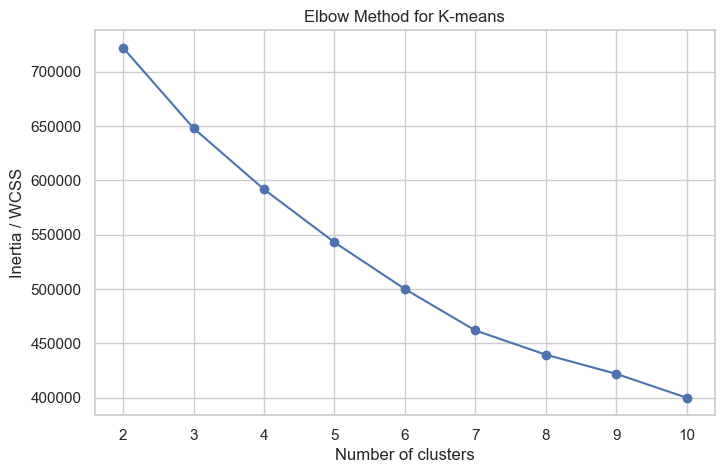

In [66]:
# =========================
# CELL 9: K-MEANS ELBOW METHOD
# =========================
# Läraren lyfter elbow method som ett sätt att välja antal kluster.
# Vi testar flera k och tittar var kurvan börjar plana ut.

inertias = []

k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_values, inertias, marker="o")

plt.title("Elbow Method for K-means")
plt.xlabel("Number of clusters")
plt.ylabel("Inertia / WCSS")
plt.show()

In [67]:
# =========================
# CELL 11: TRAIN K-MEANS
# =========================
# Välj k baserat på elbow + silhouette.
# Om du är osäker, börja med 4 eftersom det ofta ger tolkbara segment.

best_k = 4

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df_model["cluster"] = kmeans.fit_predict(X_scaled)

df_model["cluster"].value_counts().sort_index()

cluster
0    27114
1    18459
2    37039
3     6971
Name: count, dtype: int64

In [68]:
# =========================
# CELL 11: TRAIN K-MEANS
# =========================

best_k = 4

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df_model["cluster"] = kmeans.fit_predict(X_scaled)

cluster_names = {
    0: "Energetic / loud tracks",
    1: "Acoustic / calm tracks",
    2: "Danceable / positive tracks",
    3: "Live / speech-heavy tracks"
}

df_model["cluster_name"] = df_model["cluster"].map(cluster_names)

df_model["cluster"].value_counts().sort_index()

cluster
0    27114
1    18459
2    37039
3     6971
Name: count, dtype: int64

In [69]:
# =========================
# CELL 12: CLUSTER PROFILES
# =========================
# Nu tolkar vi klustren.
# Detta är centralt i storyn:
# "Vilka typer av låtar hittar algoritmen?"

cluster_profile = (
    df_model
    .groupby("cluster")[audio_features + ["popularity"]]
    .mean()
    .round(3)
)

cluster_profile

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_min,popularity
cluster,,,,,,,,,,,
0,0.486,0.797,-6.195,0.078,0.080,0.247,0.192,0.322,136.014,4.393,33.373
1,0.448,0.265,-15.160,0.052,0.788,0.351,0.157,0.284,109.680,3.603,30.403
2,0.684,0.682,-6.936,0.089,0.272,0.048,0.165,0.667,118.892,3.495,34.411
3,0.527,0.742,-7.820,0.211,0.369,0.072,0.743,0.492,120.129,3.905,33.394


In [70]:
# =========================
# CELL 13: INTERPRET CLUSTERS
# =========================
# Vi döper klustren baserat på medelvärdena i cluster_profile.
# Namnen är tolkningar, inte facit.

cluster_names = {
    0: "Energetic / loud tracks",
    1: "Acoustic / calm tracks",
    2: "Danceable / positive tracks",
    3: "Live / speech-heavy tracks"
}

df_model["cluster_name"] = df_model["cluster"].map(cluster_names)

df_model[["track_name", "artists", "popularity", "cluster", "cluster_name"]].head()

,track_name,artists,popularity,cluster,cluster_name
0,Comedy,Gen Hoshino,73,2,Danceable / positive tracks
1,Ghost - Acoustic,Ben Woodward,55,1,Acoustic / calm tracks
2,To Begin Again,Ingrid Michaelson;ZAYN,57,1,Acoustic / calm tracks
3,Can't Help Falling In Love,Kina Grannis,71,1,Acoustic / calm tracks
4,Hold On,Chord Overstreet,82,1,Acoustic / calm tracks


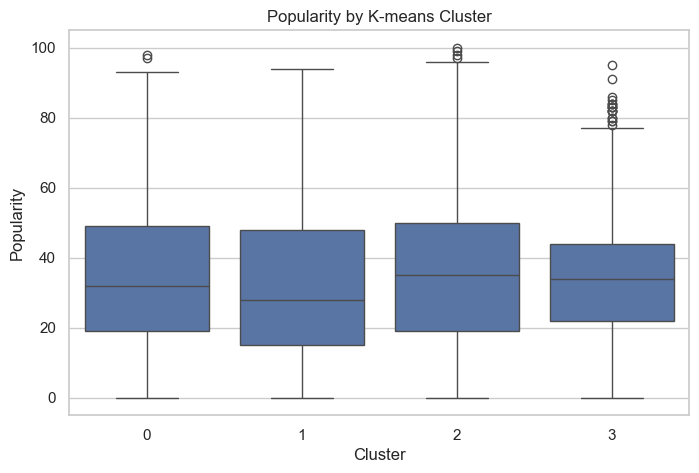

In [71]:
# =========================
# CELL 14: POPULARITY BY CLUSTER
# =========================
# Fråga:
# Är vissa låttyper mer populära än andra?

plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df_model,
    x="cluster",
    y="popularity"
)

plt.title("Popularity by K-means Cluster")
plt.xlabel("Cluster")
plt.ylabel("Popularity")
plt.show()

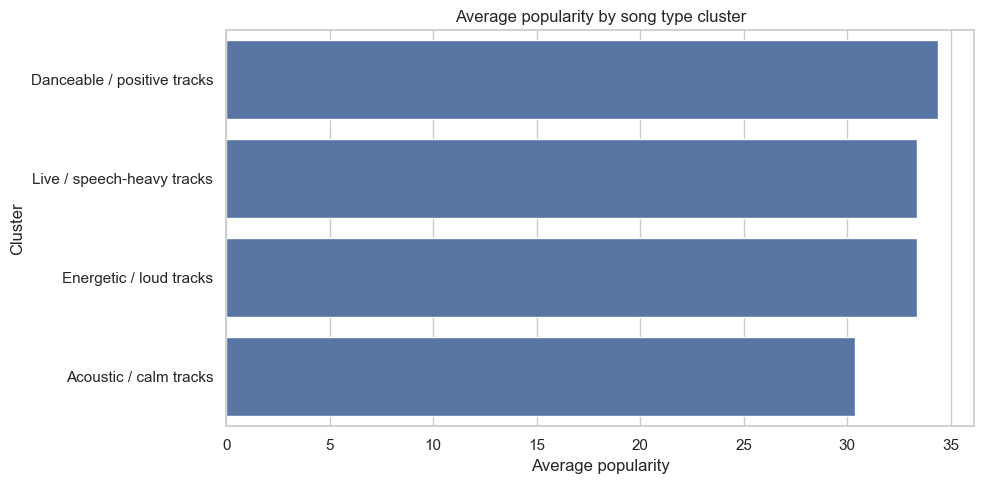

,cluster,cluster_name,mean_popularity,median_popularity,number_of_songs
2,2,Danceable / positive tracks,34.410540,35.0,37039
3,3,Live / speech-heavy tracks,33.394205,34.0,6971
0,0,Energetic / loud tracks,33.373350,32.0,27114
1,1,Acoustic / calm tracks,30.403218,28.0,18459


In [72]:
# =========================
# CELL 14.1: AVERAGE POPULARITY BY CLUSTER
# =========================
# Syfte:
# Boxploten visar spridning, men stapeldiagrammet är enklare för presentation.
# Här ser vi genomsnittlig popularity per kluster.

cluster_popularity = (
    df_model
    .groupby(["cluster", "cluster_name"])
    .agg(
        mean_popularity=("popularity", "mean"),
        median_popularity=("popularity", "median"),
        number_of_songs=("track_name", "count")
    )
    .reset_index()
    .sort_values("mean_popularity", ascending=False)
)

plt.figure(figsize=(10, 5))
sns.barplot(
    data=cluster_popularity,
    x="mean_popularity",
    y="cluster_name"
)

plt.title("Average popularity by song type cluster")
plt.xlabel("Average popularity")
plt.ylabel("Cluster")

plt.tight_layout()
plt.show()

cluster_popularity

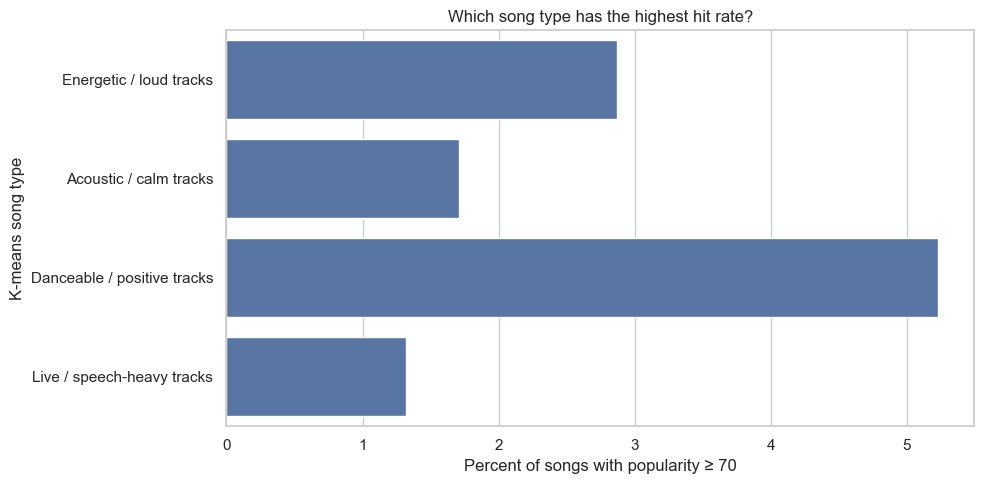

,cluster,cluster_name,number_of_songs,mean_popularity,median_popularity,hit_rate,hit_rate_percent
0,0,Energetic / loud tracks,27114,33.373350,32.0,0.028731,2.873055
1,1,Acoustic / calm tracks,18459,30.403218,28.0,0.017065,1.706485
2,2,Danceable / positive tracks,37039,34.410540,35.0,0.052323,5.232323
3,3,Live / speech-heavy tracks,6971,33.394205,34.0,0.013198,1.319753


In [73]:
# =========================
# CELL 14.2: HIT RATE BY CLUSTER
# =========================
# Syfte:
# K-means har hittat låttyper utan facit.
# Nu undersöker vi om vissa låttyper oftare blir hits.

df_model["is_hit"] = df_model["popularity"] >= 70

cluster_hit_rate = (
    df_model
    .groupby(["cluster", "cluster_name"])
    .agg(
        number_of_songs=("track_name", "count"),
        mean_popularity=("popularity", "mean"),
        median_popularity=("popularity", "median"),
        hit_rate=("is_hit", "mean")
    )
    .reset_index()
)

cluster_hit_rate["hit_rate_percent"] = cluster_hit_rate["hit_rate"] * 100

plt.figure(figsize=(10, 5))
sns.barplot(
    data=cluster_hit_rate,
    x="hit_rate_percent",
    y="cluster_name"
)

plt.title("Which song type has the highest hit rate?")
plt.xlabel("Percent of songs with popularity ≥ 70")
plt.ylabel("K-means song type")
plt.tight_layout()
plt.show()

cluster_hit_rate

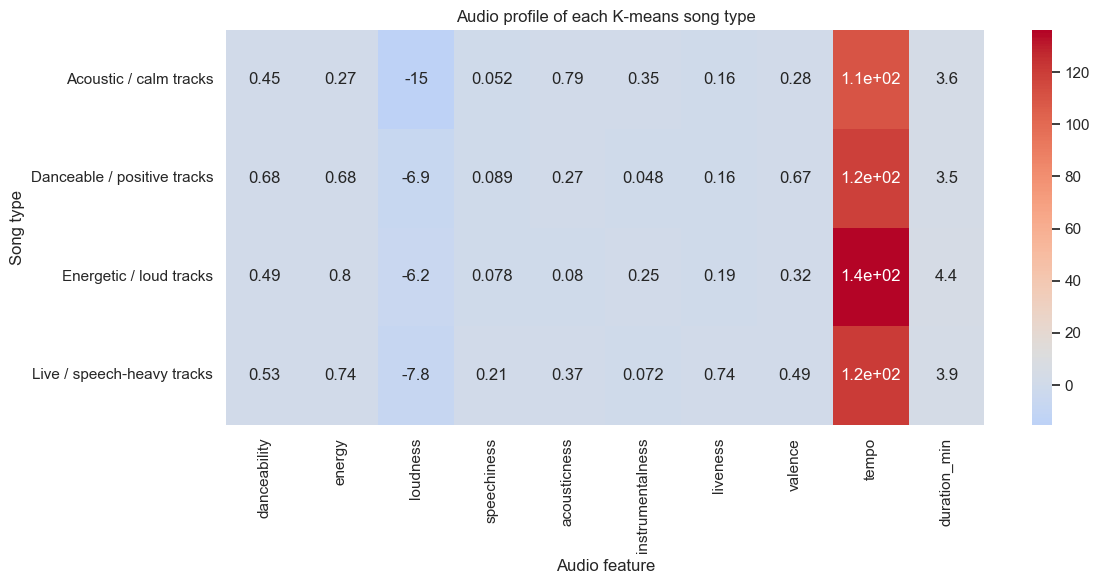

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_min
cluster_name,,,,,,,,,,
Acoustic / calm tracks,0.447827,0.265211,-15.160249,0.051633,0.788198,0.350742,0.157375,0.284447,109.679607,3.602617
Danceable / positive tracks,0.683931,0.681731,-6.935871,0.089436,0.272368,0.048063,0.164999,0.667193,118.891692,3.494773
Energetic / loud tracks,0.486051,0.796554,-6.195169,0.077825,0.080172,0.247219,0.191957,0.322325,136.013505,4.392819
Live / speech-heavy tracks,0.526674,0.742084,-7.820197,0.211045,0.368808,0.072089,0.742863,0.491802,120.129328,3.905248


In [74]:
# =========================
# CELL 14.3: CLUSTER AUDIO PROFILE HEATMAP
# =========================
# Syfte:
# Visa vad som kännetecknar varje kluster.
# Detta hjälper oss översätta kluster till musikaliska låttyper.

cluster_audio_profile = (
    df_model
    .groupby("cluster_name")[audio_features]
    .mean()
)

plt.figure(figsize=(12, 6))
sns.heatmap(
    cluster_audio_profile,
    annot=True,
    cmap="coolwarm",
    center=cluster_audio_profile.mean().mean()
)

plt.title("Audio profile of each K-means song type")
plt.xlabel("Audio feature")
plt.ylabel("Song type")
plt.tight_layout()
plt.show()

cluster_audio_profile

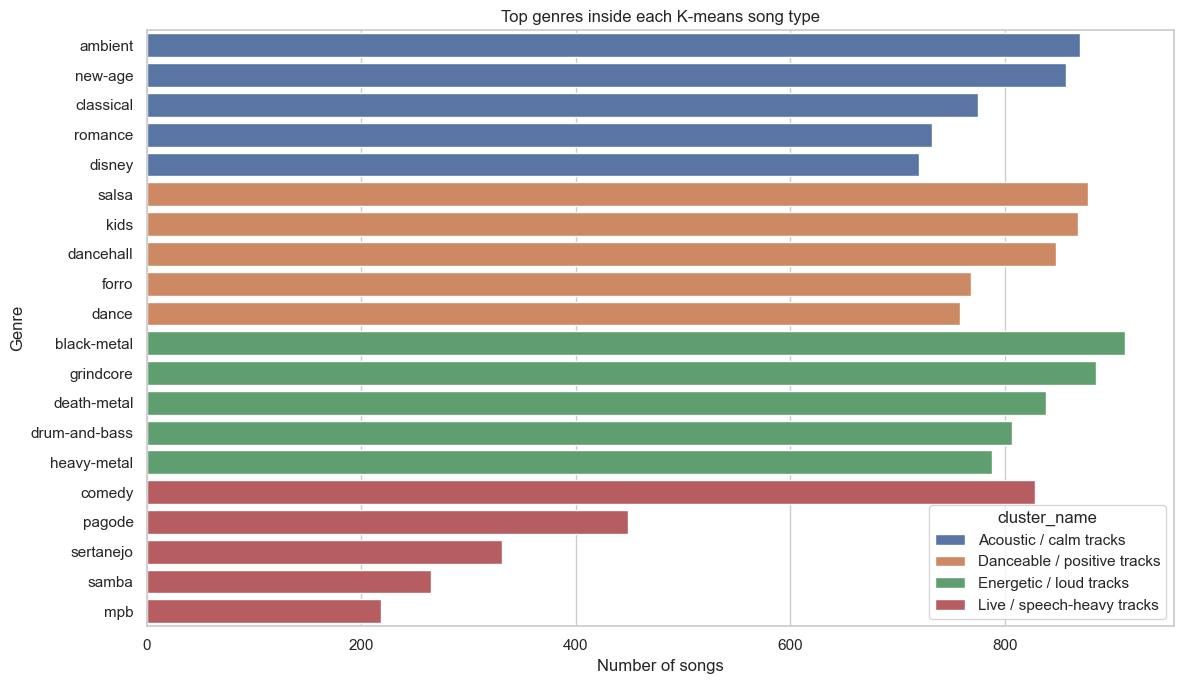

,cluster_name,track_genre,count
4,Acoustic / calm tracks,ambient,870
73,Acoustic / calm tracks,new-age,857
16,Acoustic / calm tracks,classical,775
88,Acoustic / calm tracks,romance,732
26,Acoustic / calm tracks,disney,720
202,Danceable / positive tracks,salsa,877
173,Danceable / positive tracks,kids,868
128,Danceable / positive tracks,dancehall,848
142,Danceable / positive tracks,forro,768
127,Danceable / positive tracks,dance,758


In [75]:
# =========================
# CELL 14.4: TOP GENRES BY CLUSTER
# =========================
# Syfte:
# Se vilka genres som dominerar varje algoritmiskt hittad låttyp.

top_genres_by_cluster = (
    df_model
    .groupby(["cluster_name", "track_genre"])
    .size()
    .reset_index(name="count")
    .sort_values(["cluster_name", "count"], ascending=[True, False])
)

top_5_genres_by_cluster = (
    top_genres_by_cluster
    .groupby("cluster_name")
    .head(5)
)

plt.figure(figsize=(12, 7))
sns.barplot(
    data=top_5_genres_by_cluster,
    x="count",
    y="track_genre",
    hue="cluster_name"
)

plt.title("Top genres inside each K-means song type")
plt.xlabel("Number of songs")
plt.ylabel("Genre")
plt.tight_layout()
plt.show()

top_5_genres_by_cluster

Explained variance ratio: [0.28725403 0.15338851]
Total explained variance: 0.4406425320985706


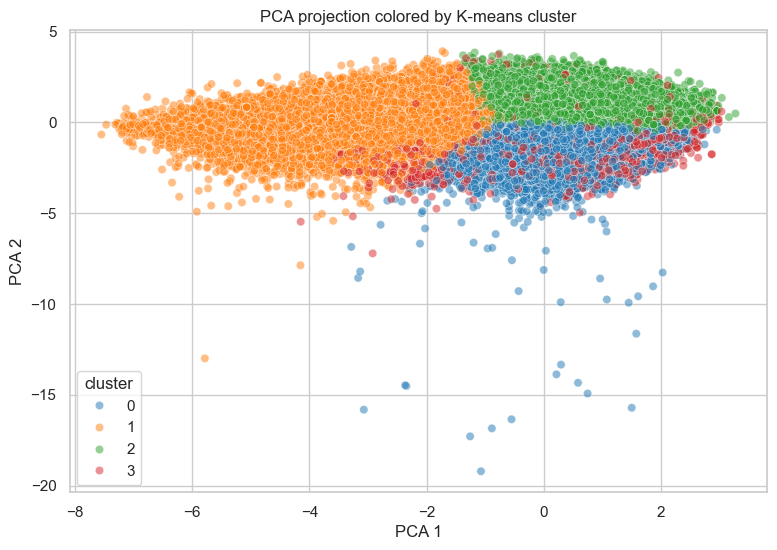

In [76]:
# =========================
# CELL 15: PCA VISUALIZATION
# =========================
# PCA reducerar många ljudvariabler till två komponenter.
# PCA skapar inte kluster, men hjälper oss att se struktur i 2D.

pca = PCA(n_components=2, random_state=42)
pca_result = pca.fit_transform(X_scaled)

df_model["pca_1"] = pca_result[:, 0]
df_model["pca_2"] = pca_result[:, 1]

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total explained variance:", pca.explained_variance_ratio_.sum())

plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=df_model,
    x="pca_1",
    y="pca_2",
    hue="cluster",
    palette="tab10",
    alpha=0.5
)

plt.title("PCA projection colored by K-means cluster")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

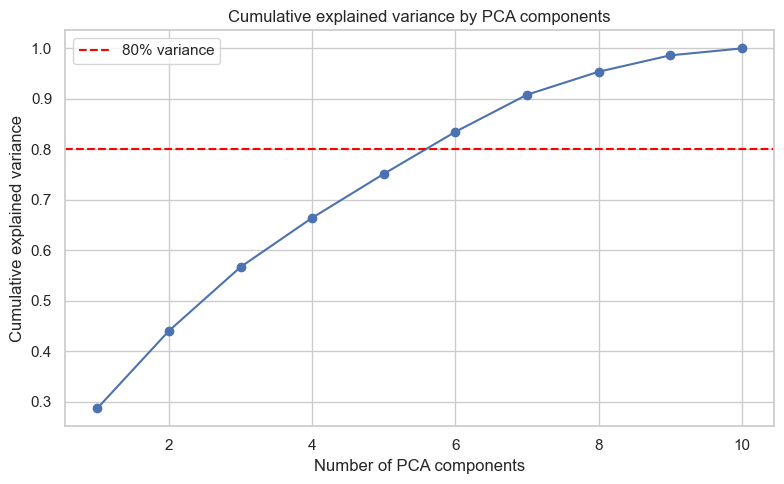

Number of components needed for at least 80% variance: 6


In [77]:
# =========================
# CELL 15.1: PCA COMPONENTS NEEDED FOR 80% VARIANCE
# =========================
# Syfte:
# Här ser vi hur många PCA-komponenter som behövs för att bevara minst 80% av variationen.
#
# Detta är separat från K-means elbow.

pca_full = PCA()
pca_full.fit(X_scaled)

explained_variance = pca_full.explained_variance_ratio_
cumulative_variance = explained_variance.cumsum()

plt.figure(figsize=(8, 5))
plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker="o"
)

plt.axhline(0.80, color="red", linestyle="--", label="80% variance")
plt.title("Cumulative explained variance by PCA components")
plt.xlabel("Number of PCA components")
plt.ylabel("Cumulative explained variance")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

n_components_80 = np.argmax(cumulative_variance >= 0.80) + 1
print("Number of components needed for at least 80% variance:", n_components_80)

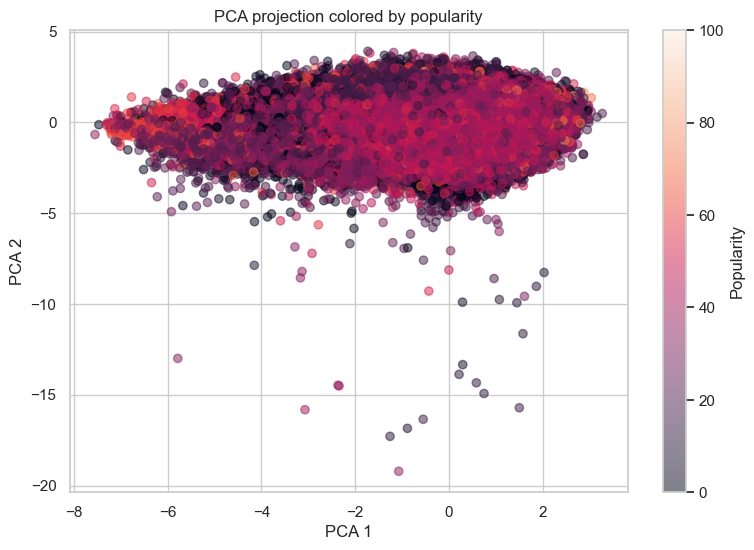

In [78]:
# =========================
# CELL 16: PCA COLORED BY POPULARITY
# =========================
# Fråga:
# Syns popularitet som ett mönster i den reducerade ljudrymden?

plt.figure(figsize=(9, 6))
scatter = plt.scatter(
    df_model["pca_1"],
    df_model["pca_2"],
    c=df_model["popularity"],
    alpha=0.5
)

plt.colorbar(scatter, label="Popularity")
plt.title("PCA projection colored by popularity")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

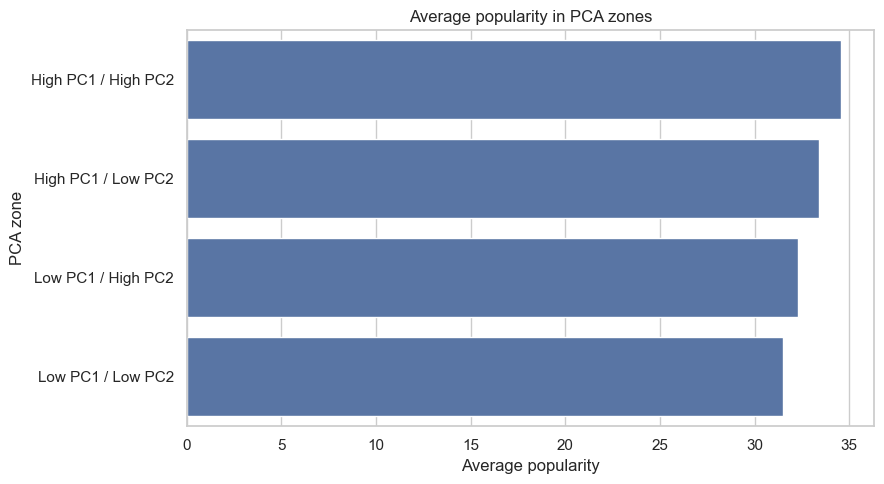

,pca_zone,mean_popularity,median_popularity,number_of_songs
0,High PC1 / High PC2,34.581614,36.0,27912
1,High PC1 / Low PC2,33.382596,32.0,26477
2,Low PC1 / High PC2,32.274832,32.0,20045
3,Low PC1 / Low PC2,31.510925,32.0,15149


In [79]:
# =========================
# CELL 16.1: POPULARITY BY PCA QUADRANTS
# =========================
# Syfte:
# Vi delar PCA-rummet i fyra zoner baserat på PC1 och PC2.
# Detta är som en mer avancerad hit matrix.

df_model["pc1_group"] = np.where(df_model["pca_1"] >= 0, "High PC1", "Low PC1")
df_model["pc2_group"] = np.where(df_model["pca_2"] >= 0, "High PC2", "Low PC2")

df_model["pca_zone"] = df_model["pc1_group"] + " / " + df_model["pc2_group"]

pca_zone_popularity = (
    df_model
    .groupby("pca_zone")
    .agg(
        mean_popularity=("popularity", "mean"),
        median_popularity=("popularity", "median"),
        number_of_songs=("track_name", "count")
    )
    .reset_index()
)

plt.figure(figsize=(9, 5))
sns.barplot(
    data=pca_zone_popularity,
    x="mean_popularity",
    y="pca_zone"
)

plt.title("Average popularity in PCA zones")
plt.xlabel("Average popularity")
plt.ylabel("PCA zone")

plt.tight_layout()
plt.show()

pca_zone_popularity

c:\Users\spiri\ws\hitsong_uml\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


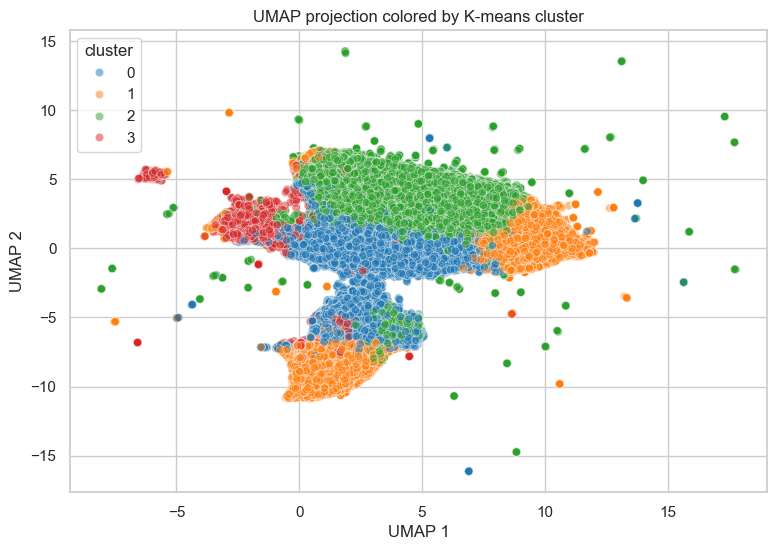

In [80]:
# =========================
# CELL 17: UMAP VISUALIZATION
# =========================
# UMAP är också dimensionsreduktion men kan fånga mer komplexa, icke-linjära strukturer.
# Om den här cellen ger ModuleNotFoundError:
# kör i terminalen: pip install umap-learn

import umap.umap_ as umap

umap_model = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    random_state=42
)

umap_result = umap_model.fit_transform(X_scaled)

df_model["umap_1"] = umap_result[:, 0]
df_model["umap_2"] = umap_result[:, 1]

plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=df_model,
    x="umap_1",
    y="umap_2",
    hue="cluster",
    palette="tab10",
    alpha=0.5
)

plt.title("UMAP projection colored by K-means cluster")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.show()

c:\Users\spiri\ws\hitsong_uml\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


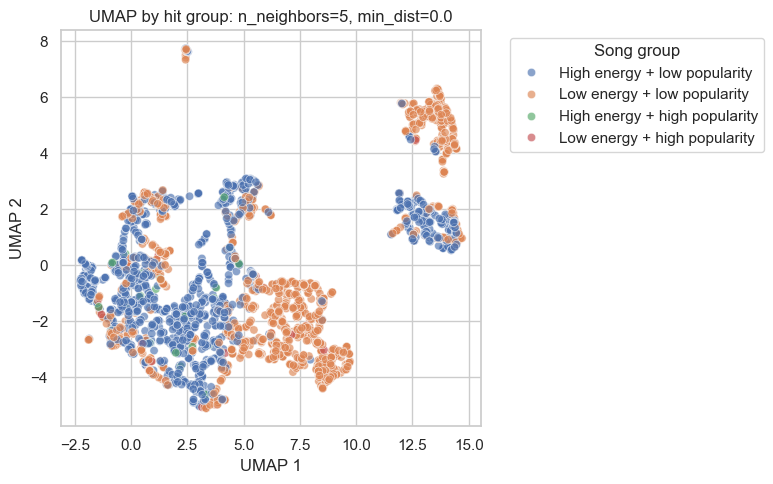

c:\Users\spiri\ws\hitsong_uml\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


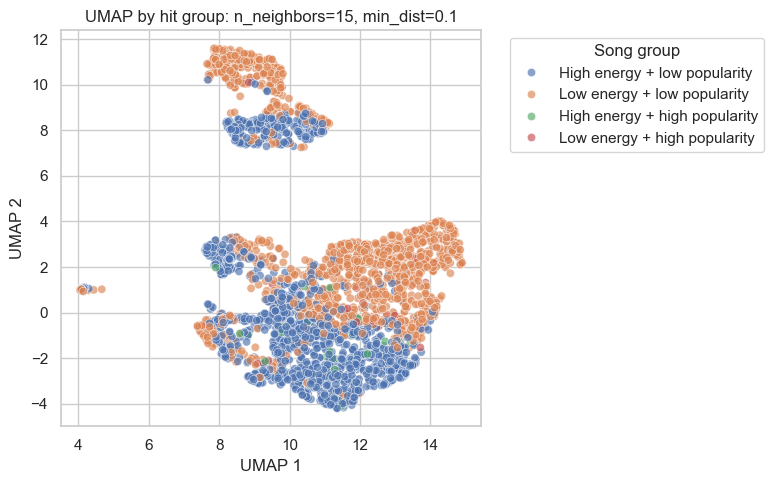

c:\Users\spiri\ws\hitsong_uml\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


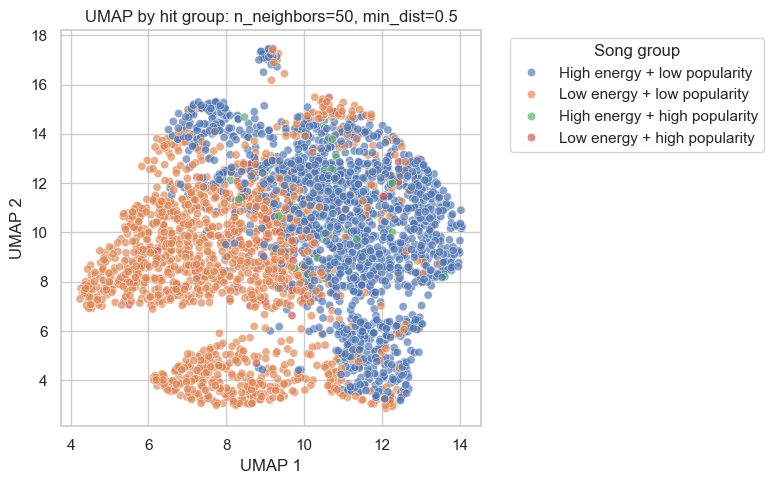

In [81]:
# =========================
# CELL 18: FAST UMAP HYPERPARAMETER TEST
# =========================

umap_sample = df_model.sample(n=3000, random_state=42).copy()

X_umap_sample = umap_sample[audio_features].copy()
X_umap_scaled = scaler.fit_transform(X_umap_sample)

settings = [
    {"n_neighbors": 5, "min_dist": 0.0},
    {"n_neighbors": 15, "min_dist": 0.1},
    {"n_neighbors": 50, "min_dist": 0.5}
]

for setting in settings:
    model = umap.UMAP(
        n_neighbors=setting["n_neighbors"],
        min_dist=setting["min_dist"],
        random_state=42
    )
    
    emb = model.fit_transform(X_umap_scaled)
    
    plt.figure(figsize=(8, 5))
    sns.scatterplot(
        x=emb[:, 0],
        y=emb[:, 1],
        hue=umap_sample["hit_matrix_group"],
        alpha=0.65
    )
    
    plt.title(
        f"UMAP by hit group: n_neighbors={setting['n_neighbors']}, min_dist={setting['min_dist']}"
    )
    plt.xlabel("UMAP 1")
    plt.ylabel("UMAP 2")
    plt.legend(title="Song group", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

In [82]:
# =========================
# CELL 18.1: INTERACTIVE UMAP
# =========================

model = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    random_state=42
)

emb = model.fit_transform(X_umap_scaled)

umap_plot_df = umap_sample.copy()
umap_plot_df["umap_1"] = emb[:, 0]
umap_plot_df["umap_2"] = emb[:, 1]

fig = px.scatter(
    umap_plot_df,
    x="umap_1",
    y="umap_2",
    color="hit_matrix_group",
    hover_data=[
        "track_name",
        "artists",
        "track_genre",
        "popularity",
        "energy",
        "danceability"
    ],
    title="Interactive UMAP: Song groups"
)

fig.update_layout(width=950, height=650)

fig.show(renderer="browser")

fig.write_html(results_path / "interactive_umap_hit_groups.html")

c:\Users\spiri\ws\hitsong_uml\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [83]:
# =========================
# CELL 18.2: INTERACTIVE 3D UMAP
# =========================
# Syfte:
# 3D UMAP kan ibland separera grupper tydligare än 2D.

model_3d = umap.UMAP(
    n_components=3,
    n_neighbors=15,
    min_dist=0.1,
    random_state=42
)

emb_3d = model_3d.fit_transform(X_umap_scaled)

umap_3d_df = umap_sample.copy()
umap_3d_df["umap_1"] = emb_3d[:, 0]
umap_3d_df["umap_2"] = emb_3d[:, 1]
umap_3d_df["umap_3"] = emb_3d[:, 2]

fig = px.scatter_3d(
    umap_3d_df,
    x="umap_1",
    y="umap_2",
    z="umap_3",
    color="hit_matrix_group",
    hover_data=[
        "track_name",
        "artists",
        "track_genre",
        "popularity",
        "energy",
        "danceability"
    ],
    title="Interactive 3D UMAP: Song groups",
    opacity=0.7
)

fig.update_layout(
    width=1000,
    height=750,
    legend_title_text="Song group"
)

fig.show(renderer="browser")

fig.write_html(results_path / "interactive_3d_umap_hit_groups.html")

c:\Users\spiri\ws\hitsong_uml\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [84]:
# =========================
# CELL 19-21: ISOLATION FOREST + UNIQUE HITS
# =========================

iso = IsolationForest(
    contamination=0.01,
    random_state=42
)

df_model["anomaly_label"] = iso.fit_predict(X_scaled)
df_model["anomaly_score"] = iso.decision_function(X_scaled)

anomalies = df_model[df_model["anomaly_label"] == -1].copy()

unique_hits = anomalies[anomalies["popularity"] >= 70].sort_values(
    "popularity",
    ascending=False
)

print("Anomalies:", anomalies.shape)
print("Unique hits:", unique_hits.shape)

unique_hits.head()

Anomalies: (896, 27)
Unique hits: (3, 27)


,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_min,...,cluster_name,pca_1,pca_2,pc1_group,pc2_group,pca_zone,umap_1,umap_2,anomaly_label,anomaly_score
79985,0.0555,0.08370,-30.397,0.1470,0.116,1.000,0.112,0.06000,59.509,4.133333,...,Acoustic / calm tracks,-5.323870,-1.744150,Low PC1,Low PC2,Low PC1 / Low PC2,-0.183082,-9.834992,-1,-0.042323
80030,0.1790,0.00189,-25.200,0.3270,0.982,0.279,0.111,0.00001,81.710,9.918417,...,Acoustic / calm tracks,-5.084228,-1.191104,Low PC1,Low PC2,Low PC1 / Low PC2,-0.282618,-8.449797,-1,-0.055164
79936,0.0685,0.00342,-37.156,0.0418,0.990,0.910,0.106,0.05810,73.644,2.872617,...,Acoustic / calm tracks,-7.186268,-0.546995,Low PC1,Low PC2,Low PC1 / Low PC2,-0.514799,-10.783203,-1,-0.005830


In [85]:
# =========================
# CELL 19: ISOLATION FOREST
# =========================
# Läraren går igenom Isolation Forest som anomalidetektion.
# Här letar vi efter låtar som har ovanlig ljudprofil.
# I vår story kan detta bli:
# "unika hits" eller "missförstådda låtar".

iso = IsolationForest(
    contamination=0.01,
    random_state=42
)

df_model["anomaly_label"] = iso.fit_predict(X_scaled)
df_model["anomaly_score"] = iso.decision_function(X_scaled)

print(df_model["anomaly_label"].value_counts())

anomaly_label
 1    88687
-1      896
Name: count, dtype: int64


In [86]:
# =========================
# CELL 20: INSPECT ANOMALIES
# =========================
# anomaly_label = -1 betyder att modellen flaggar låten som ovanlig.

anomalies = df_model[df_model["anomaly_label"] == -1].copy()

anomalies[
    [
        "track_name",
        "artists",
        "track_genre",
        "popularity",
        "danceability",
        "energy",
        "valence",
        "tempo",
        "cluster",
        "anomaly_score"
    ]
].sort_values("popularity", ascending=False).head(20)

,track_name,artists,track_genre,popularity,danceability,energy,valence,tempo,cluster,anomaly_score
79985,Brown Sleep Noise,Sleep Miracle,sleep,80,0.0555,0.083700,0.06000,59.509,1,-0.042323
80030,White Noise Sleeping Aid to Help My Baby Fall ...,White Noise Baby Sleep,sleep,75,0.1790,0.001890,0.00001,81.710,1,-0.055164
79936,Herinneringen,Sohn Aelia,sleep,74,0.0685,0.003420,0.05810,73.644,1,-0.005830
79981,Weißes Rauschen: Baby Schlafhilfe,Weißes Rauschen HD,sleep,67,0.0788,0.000099,0.00000,168.156,1,-0.040526
80432,Calming Pacific Ocean Roar to Induce Healing D...,White Noise Baby Sleep,sleep,66,0.0844,0.199000,0.00001,87.404,1,-0.051227
80293,Anatomy of Change,Oto Roth,sleep,66,0.1310,0.003330,0.03490,81.947,1,-0.011946
80247,Maglovito,Nadia Bulic,sleep,65,0.1070,0.002260,0.09900,68.013,1,-0.000897
14317,let me hold you,lofi.samurai;Insowmya,chill,65,0.5330,0.331000,0.23000,69.527,3,-0.026231
80139,Sonder,Modal Colours,sleep,65,0.1180,0.002160,0.05910,72.639,1,-0.005530
80195,Een mooie droom,Zeb Maessen,sleep,65,0.0983,0.004860,0.03710,65.583,1,-0.011681


In [87]:
# =========================
# CELL 21: UNIQUE HITS
# =========================
# Här söker vi låtar som är både:
# - populära
# - ovanliga enligt Isolation Forest
# Det passar er presentationstwist.

unique_hits = anomalies[anomalies["popularity"] >= 70].sort_values(
    "popularity",
    ascending=False
)

unique_hits[
    ["track_name", "artists", "track_genre", "popularity", "cluster", "anomaly_score"]
].head(20)

,track_name,artists,track_genre,popularity,cluster,anomaly_score
79985,Brown Sleep Noise,Sleep Miracle,sleep,80,1,-0.042323
80030,White Noise Sleeping Aid to Help My Baby Fall ...,White Noise Baby Sleep,sleep,75,1,-0.055164
79936,Herinneringen,Sohn Aelia,sleep,74,1,-0.005830


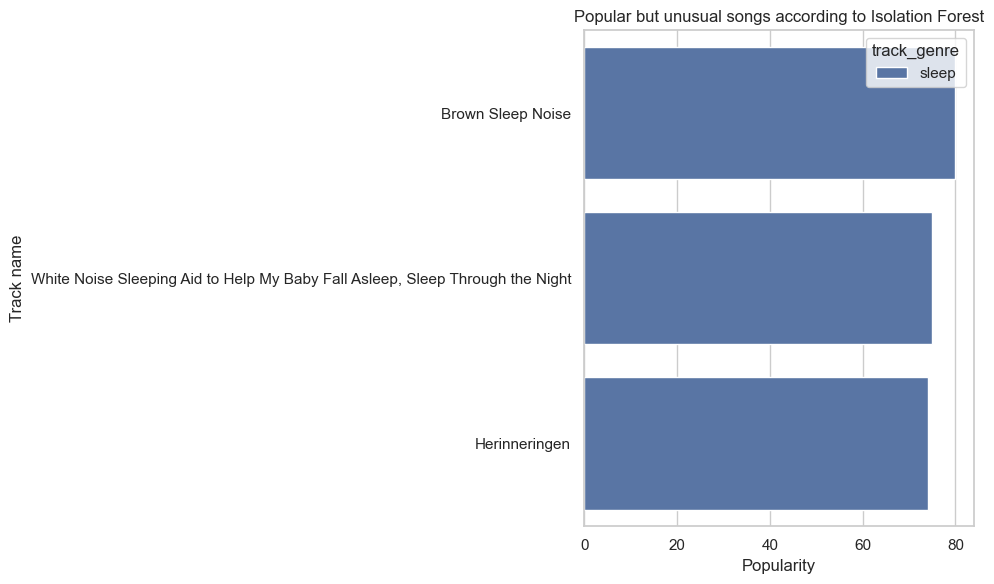

,track_name,artists,track_genre,popularity,danceability,energy,valence,tempo,anomaly_score
79985,Brown Sleep Noise,Sleep Miracle,sleep,80,0.0555,0.08370,0.06000,59.509,-0.042323
80030,White Noise Sleeping Aid to Help My Baby Fall ...,White Noise Baby Sleep,sleep,75,0.1790,0.00189,0.00001,81.710,-0.055164
79936,Herinneringen,Sohn Aelia,sleep,74,0.0685,0.00342,0.05810,73.644,-0.005830


In [88]:
# =========================
# CELL 21.1: VISUALIZE UNIQUE HITS
# =========================
# Syfte:
# Visa populära anomalier visuellt.
# Det här hjälper presentationen:
# "Alla populära låtar är inte klassiska hits. Vissa är funktionella ljud."

top_unique_hits = unique_hits.head(10)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_unique_hits,
    x="popularity",
    y="track_name",
    hue="track_genre"
)

plt.title("Popular but unusual songs according to Isolation Forest")
plt.xlabel("Popularity")
plt.ylabel("Track name")

plt.tight_layout()
plt.show()

top_unique_hits[
    ["track_name", "artists", "track_genre", "popularity", "danceability", "energy", "valence", "tempo", "anomaly_score"]
]

In [89]:
# =========================
# CELL 22: DUPLICATE / GENRE ANALYSIS
# =========================
# Nu använder vi datasetet MED dubbletter.
# Fråga:
# Förekommer samma låt i flera genres?
# Och kan genrebredd vara kopplad till popularity?

duplicate_tracks = df_dup[df_dup.duplicated(subset=["track_id"], keep=False)].copy()

genre_count_per_track = (
    duplicate_tracks
    .groupby(["track_id", "artists", "track_name"])
    .agg(
        number_of_genres=("track_genre", "nunique"),
        mean_popularity=("popularity", "mean"),
        max_popularity=("popularity", "max"),
        genres=("track_genre", lambda x: ", ".join(sorted(x.unique())))
    )
    .reset_index()
    .sort_values("number_of_genres", ascending=False)
)

genre_count_per_track.head(20)

,track_id,artists,track_name,number_of_genres,mean_popularity,max_popularity,genres
13819,6S3JlDAGk3uu3NtZbPnuhS,Badfinger,Baby Blue - Remastered 2010,9,67.000000,67,"blues, country, folk, j-pop, j-rock, power-pop..."
5866,2kkvB3RNRzwjFdGhaUA0tz,Derek & The Dominos,Layla,8,74.000000,74,"blues, british, country, folk, hard-rock, psyc..."
4797,2Ey6v4Sekh3Z0RUSISRosD,Derek & The Dominos,Layla,8,0.000000,0,"blues, british, country, folk, hard-rock, psyc..."
6627,36NwMJRaCy7x77xYGJiG2M,Allman Brothers Band,Midnight Rider,7,1.000000,1,"blues, country, folk, hard-rock, j-rock, singe..."
16415,7tbzfR8ZvZzJEzy6v0d6el,Ritviz,Liggi,7,68.000000,68,"edm, hip-hop, indian, indie, indie-pop, pop, p..."
5511,2aaClnypAakdAmLw74JXxB,Sepultura,Arise,7,0.000000,0,"alt-rock, brazil, death-metal, groove, hard-ro..."
6054,2qgXrzJsry4KgYoJCpuaul,The Local Train,Choo Lo,7,67.000000,67,"hip-hop, indian, indie, indie-pop, pop, pop-fi..."
6233,2vU6bm5hVF2idVknGzqyPL,The Offspring,Christmas (Baby Please Come Home),7,0.000000,0,"alt-rock, alternative, metal, punk, punk-rock,..."
310,08kTa3SL9sV6Iy8KLKtGql,Prateek Kuhad,Kasoor,7,70.000000,70,"folk, indian, indie, indie-pop, pop, singer-so..."
941,0RSGPiykniIg8m7JhiAVv7,Anupam Roy,Aisi Raaton,7,62.000000,62,"indian, indie, indie-pop, k-pop, pop-film, sin..."


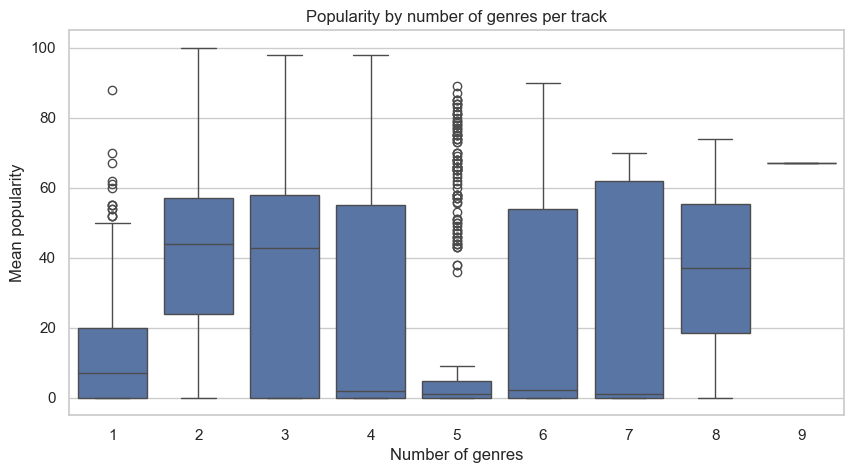

In [90]:
# =========================
# CELL 23: POPULARITY AND GENRE BREADTH
# =========================
# Fråga:
# Har låtar som förekommer i fler genres högre popularity?

plt.figure(figsize=(10, 5))
sns.boxplot(
    data=genre_count_per_track,
    x="number_of_genres",
    y="mean_popularity"
)

plt.title("Popularity by number of genres per track")
plt.xlabel("Number of genres")
plt.ylabel("Mean popularity")
plt.show()

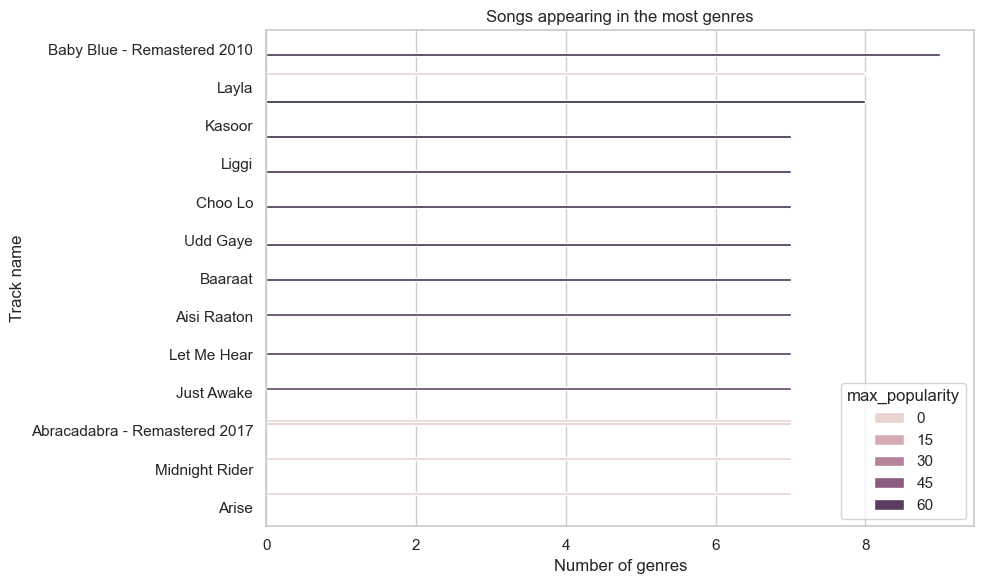

,artists,track_name,number_of_genres,mean_popularity,max_popularity,genres
13819,Badfinger,Baby Blue - Remastered 2010,9,67.000000,67,"blues, country, folk, j-pop, j-rock, power-pop..."
5866,Derek & The Dominos,Layla,8,74.000000,74,"blues, british, country, folk, hard-rock, psyc..."
4797,Derek & The Dominos,Layla,8,0.000000,0,"blues, british, country, folk, hard-rock, psyc..."
310,Prateek Kuhad,Kasoor,7,70.000000,70,"folk, indian, indie, indie-pop, pop, singer-so..."
16415,Ritviz,Liggi,7,68.000000,68,"edm, hip-hop, indian, indie, indie-pop, pop, p..."
6054,The Local Train,Choo Lo,7,67.000000,67,"hip-hop, indian, indie, indie-pop, pop, pop-fi..."
11886,Ritviz,Udd Gaye,7,67.000000,67,"edm, hip-hop, indian, indie, indie-pop, pop, p..."
1204,Ritviz;Nucleya,Baaraat,7,66.000000,66,"edm, hip-hop, indian, indie, indie-pop, pop, p..."
941,Anupam Roy,Aisi Raaton,7,62.000000,62,"indian, indie, indie-pop, k-pop, pop-film, sin..."
12564,"Fear, and Loathing in Las Vegas",Let Me Hear,7,61.857143,62,"hard-rock, hardcore, j-pop, j-rock, metal, met..."


In [91]:
# =========================
# CELL 23.1: TRACKS IN MANY GENRES
# =========================
# Syfte:
# Visa de låtar som finns i flest genres och deras popularity.
#
# Detta passar storyn:
# "Vissa låtar lever i flera musikvärldar. Är det en styrka?"

top_multi_genre_tracks = genre_count_per_track.sort_values(
    ["number_of_genres", "max_popularity"],
    ascending=False
).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_multi_genre_tracks,
    x="number_of_genres",
    y="track_name",
    hue="max_popularity"
)

plt.title("Songs appearing in the most genres")
plt.xlabel("Number of genres")
plt.ylabel("Track name")

plt.tight_layout()
plt.show()

top_multi_genre_tracks[
    ["artists", "track_name", "number_of_genres", "mean_popularity", "max_popularity", "genres"]
]

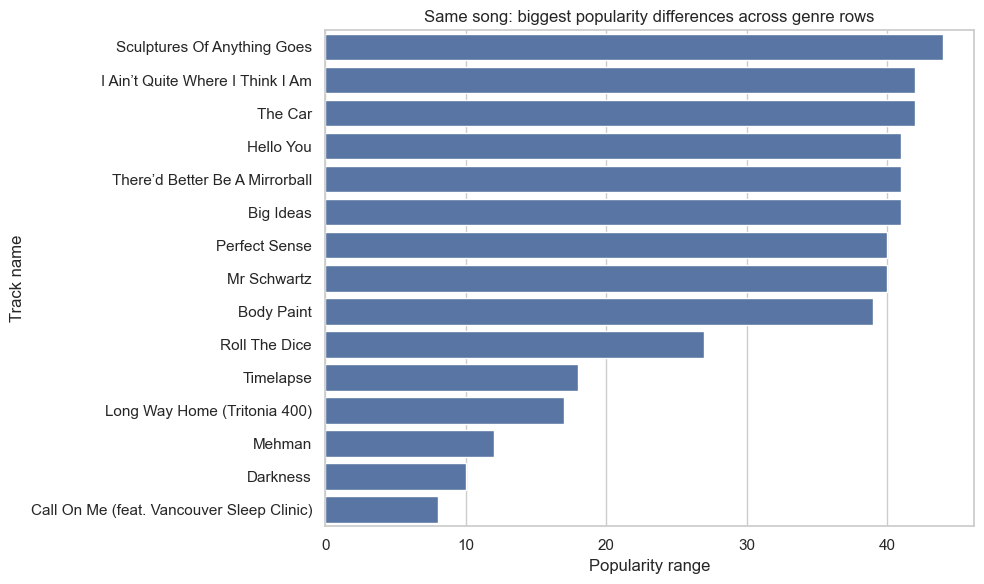

,track_id,artists,track_name,number_of_genres,min_popularity,max_popularity,popularity_range,genres
12183,5hljqZrl0h7RcIhUnOPuve,Arctic Monkeys,Sculptures Of Anything Goes,3,0,44,44,"garage, indie, rock"
3287,1UwUhKmFxGKs59xiWO60Sx,Arctic Monkeys,I Ain’t Quite Where I Think I Am,3,0,42,42,"garage, indie, rock"
422,0C6dSPCqwKqwos6s1CrDrh,Arctic Monkeys,The Car,3,0,42,42,"garage, indie, rock"
12772,5ygEUpyZy5qtZ1423zymBW,Arctic Monkeys,Hello You,3,0,41,41,"garage, indie, rock"
4288,1zx6GSqLYI2ynzAHnPRKBR,Arctic Monkeys,There’d Better Be A Mirrorball,3,0,41,41,"garage, indie, rock"
9229,4KPi4VNvPOfKqIp1sx19Xf,Arctic Monkeys,Big Ideas,3,0,41,41,"garage, indie, rock"
2144,0z5x3VmmQ7cyTeOP7VAf3T,Arctic Monkeys,Perfect Sense,3,0,40,40,"garage, indie, rock"
12075,5fClRRa7P9nPIpstj50veV,Arctic Monkeys,Mr Schwartz,3,0,40,40,"garage, indie, rock"
8607,42GuKw49pPxNAkIhWGwgFs,Arctic Monkeys,Body Paint,3,0,39,39,"garage, indie, rock"
406,0BhLfxWA4TwGu8bGVKBotN,Armin van Buuren;Philip Strand,Roll The Dice,2,0,27,27,"progressive-house, trance"


In [92]:
# =========================
# CELL 23.2: POPULARITY VARIATION ACROSS GENRES
# =========================
# Syfte:
# Här undersöker vi om samma track_id har olika popularity beroende på genre-rad.
#
# Om variationen är stor kan det betyda att genreplacering eller datasetets genrestruktur påverkar analysen.

genre_variation = (
    duplicate_tracks
    .groupby(["track_id", "artists", "track_name"])
    .agg(
        number_of_genres=("track_genre", "nunique"),
        min_popularity=("popularity", "min"),
        max_popularity=("popularity", "max"),
        popularity_range=("popularity", lambda x: x.max() - x.min()),
        genres=("track_genre", lambda x: ", ".join(sorted(x.unique())))
    )
    .reset_index()
    .sort_values("popularity_range", ascending=False)
)

top_variation = genre_variation.head(15)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_variation,
    x="popularity_range",
    y="track_name"
)

plt.title("Same song: biggest popularity differences across genre rows")
plt.xlabel("Popularity range")
plt.ylabel("Track name")

plt.tight_layout()
plt.show()

top_variation

In [93]:
# =========================
# CELL 24: SAVE RESULT FILE
# =========================
# Vi sparar datasetet med kluster och anomalier.
# Det kan teamet använda till presentation eller vidare analys.

output_path = project_folder / "data" / "spotify_unique_tracks_with_clusters.csv"

df_model.to_csv(output_path, index=False)

print("Saved file:", output_path)
print("Exists:", output_path.exists())

Saved file: c:\Users\spiri\ws\hitsong_uml\data\spotify_unique_tracks_with_clusters.csv
Exists: True
